# Real IRD order 8: iid + jitter vs Matérn-3/2 GP + jitter

Development/diagnostic comparison on `feature/spectral-gp-likelihood`; CPU / float64.
This is one order and one short chain per likelihood, not a validated stellar measurement.
The exposure is **IRDA00042313_H**; the supplied CSV does not establish a star name.

Preserve the original pixels, fixed mask, physical priors and iid analysis. Only the
noise covariance differs in the main comparison. Inputs: frozen
`characterization/sample_data_ird.csv` (identical to `data/IRDA00042313_H.csv`),
frozen Coelho `15239-15449_normed.npz`, and the existing common
`benchmark-results/ird-order8-log.npz` (1 km/s). Wavelength medium remains unknown;
CSV nm are converted to Å, with no guessed air/vacuum conversion.

Run top-to-bottom with the spectral-inference dependencies and frozen sibling present.
The mask is concrete before inference. GP uses the normal `model_single` API and
`gp_solver="auto"` (tinygp quasisep on CPU, direct on GPU), without `jit_model_args=True`.
Library arrays remain dynamic arguments. Local outputs stay under ignored
`benchmark-results/real-order8-exploration/`; only compact tables and figures are
embedded here. The read-only legacy and continuum-degree checks remain as an appendix.


In [1]:
from pathlib import Path
import os, sys, json, hashlib, platform
from importlib.metadata import version
from functools import partial
from time import perf_counter
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents]
            if (p / 'src/jaxstar/specfit/numpyro_model.py').exists())
REFERENCE = ROOT.parent / 'jaxspec'
OUTPUT = ROOT / 'benchmark-results/real-order8-exploration'
OUTPUT.mkdir(parents=True, exist_ok=True)
os.environ.setdefault('JAX_PLATFORMS', 'cpu')  # select before importing JAX
os.environ['MPLCONFIGDIR'] = str(OUTPUT / 'matplotlib')
sys.path[:0] = [str(ROOT / 'src'), str(ROOT / 'examples'), str(ROOT / 'benchmarks')]
import jax
jax.config.update('jax_enable_x64', True)
import jax.numpy as jnp
import numpy as np
import pandas as pd
get_ipython().run_line_magic('matplotlib', 'inline')
import matplotlib.pyplot as plt
import numpyro
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS, SVI, Trace_ELBO, init_to_value
from numpyro.infer.autoguide import AutoLaplaceApproximation
from numpyro.infer.util import log_density
from numpyro.diagnostics import summary as chain_summary
from jaxstar.specfit import (model_single, single_star_params, chebyshev_basis,
    continuum_posterior, evaluate_continuum, apply_continuum,
    gp_continuum_posterior, gp_conditional_mean)
from spectral_inference_real_setup import load_ird_order8
from benchmark_spectral_inference import timed_svi
from IPython.display import display, Markdown, Image
plt.rcParams.update({'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': .15})
environment = dict(python=platform.python_version(), jax=jax.__version__,
                   numpyro=numpyro.__version__, devices=[str(x) for x in jax.devices()],
                   precision='float64', tinygp=version('tinygp'),
                   branch='feature/spectral-gp-likelihood')
print(environment)

{'python': '3.12.11', 'jax': '0.6.2', 'numpyro': '0.19.0', 'devices': ['TFRT_CPU_0'], 'precision': 'float64', 'tinygp': '0.3.0', 'branch': 'feature/spectral-gp-likelihood'}


## Pixels, coverage, and fixed initial masks

Reuse the existing helper, with `stride=1`: original zero-based order-8
indices **32:2016** (edge crop only; no thinning). `all_mask=True` excludes
a pixel. Nonfinite flux/error and nonpositive errors are also excluded by
the existing data-validity helper. This mask is frozen for the entire run.
Mask columns already include historical data-level exclusions; they are not
re-estimated from our residuals. Model spectra are evaluated at the actual
observed wavelengths, not at indices of the prepared log grid.

In [2]:
RV_INITIAL = -23.588105813398162  # saved legacy check_ccf output; not measured here
LEGACY_BROAD_LIMIT = 17.301730173017305  # saved legacy CCF width / vsini prior cap
artifact = ROOT / 'benchmark-results/ird-order8-log.npz'
# Reuse the existing artifact; the helper converts the supplied legacy NPZ once if absent.
case = load_ird_order8(REFERENCE, artifact, rv_initial=RV_INITIAL, stride=1)
obs, specmodel = case.observation, case.specmodel
basis = chebyshev_basis(obs.wavelength, degree=4)
original = pd.read_csv(REFERENCE / 'characterization/sample_data_ird.csv')
frame = original.loc[original.order == 8].iloc[32:2016]
np.testing.assert_array_equal(np.asarray(obs.wavelength)[0], frame.lam.to_numpy() * 10.)
np.testing.assert_array_equal(np.asarray(obs.mask)[0],
    frame.all_mask.to_numpy(dtype=bool) | ~np.isfinite(frame.normed_flux)
    | ~np.isfinite(frame.flux_error) | (frame.flux_error <= 0))
mask_before = np.asarray(obs.mask).copy()
good = np.asarray(obs.valid)[0]
x, y, error = [np.asarray(a)[0] for a in (obs.wavelength, obs.flux, obs.uncertainty)]
library_wave = np.asarray(specmodel.spectra.wavelength)[0]
separation = np.min(np.abs(x[:, None] - library_wave[None, :]), axis=1)
digest = lambda p: hashlib.sha256(p.read_bytes()).hexdigest()
assert digest(REFERENCE / 'characterization/sample_data_ird.csv') == digest(REFERENCE / 'data/IRDA00042313_H.csv')
data_checks = dict(shape=list(obs.shape), usable=int(good.sum()), masked=int((~good).sum()),
    region=list(obs.region), order=list(obs.order), observed_range=[float(x[0]), float(x[-1])],
    model_range=[float(library_wave[0]), float(library_wave[-1])], model_pixels=len(library_wave),
    extra_invalid_exclusions=int((~good).sum() - frame.all_mask.sum()),
    grid_separation_min=float(separation.min()), grid_separation_median=float(np.median(separation)),
    median_uncertainty=float(np.median(error[good])), wavelength_medium=specmodel.spectra.wavelength_medium,
    flux_kind=specmodel.spectra.flux_kind, sources=list(specmodel.spectra.sources),
    data_sha256=digest(REFERENCE / 'characterization/sample_data_ird.csv'), artifact_sha256=digest(artifact))
assert separation.min() > 0  # no assumption of coincident sampling
print(json.dumps(data_checks, indent=2))
display(pd.DataFrame({'original_pixel': np.arange(32,2016)[::400],
                      'wavelength_A': x[::400], 'nearest_grid_difference_A': separation[::400],
                      'excluded': (~good)[::400]}))

{
  "shape": [
    1,
    1984
  ],
  "usable": 1546,
  "masked": 438,
  "region": [
    8
  ],
  "order": [
    8
  ],
  "observed_range": [
    15248.410063698031,
    15442.50586188498
  ],
  "model_range": [
    15239.0046963448,
    15448.9499815044
  ],
  "model_pixels": 4103,
  "extra_invalid_exclusions": 0,
  "grid_separation_min": 3.624386044975836e-05,
  "grid_separation_median": 0.013292797815665836,
  "median_uncertainty": 0.01792074441056425,
  "wavelength_medium": "unknown",
  "flux_kind": "normalized",
  "sources": [
    "../jaxspec/characterization/sample_grid_coelho/15239-15449_normed.npz"
  ],
  "data_sha256": "5e53f9db8d152682dc65aaeb14a412e71d02b990f6efc9d339009f2aa5919d19",
  "artifact_sha256": "e29cc63c997558ad5be456e4cae625eaff20677436dad8588548c171a002c9a5"
}


,original_pixel,wavelength_A,nearest_grid_difference_A,excluded
0,32,15248.410064,0.001427,True
1,432,15300.414929,0.016446,False
2,832,15346.093136,0.018000,False
3,1232,15385.273445,0.011279,False
4,1632,15417.784618,0.019850,False


## Explicit example-specific priors

Atmosphere: Teff U(3500,7000) K, logg U(3,5), [Fe/H] U(-1,0.5), alpha U(0,0.4).
The logg range follows frozen `examples/make_coelho_grid.py` and its older
`examples/numpyro_model.py`, both of which use 3–5. The supplied characterization
grid also includes logg 1–2; those nodes remain available but are outside this
example-specific prior. The old notebook's external `~/data/specgrid_irdh_coelho`
is unavailable, so its exact historical grid identity cannot be verified.
An initial run allowing the full 1–5 gravity range is preserved separately
and compared below; the final main run uses the documented historical range.
Rotation U(0,17.3017) and vmacro U(0,10) km/s follow the saved legacy width
and range. RV U(initial-5,initial+5) km/s follows its initialization convention.

R=70000 is fixed, as in the legacy calibration. q1=q2=0.5 are fixed near the
old broad, weakly constrained posterior medians; this reduces broadening
degeneracy for this first run (old q1/q2 were sampled). No empirical relations
or conditional gravity bound are used. The old NUTS example enabled a
Teff-dependent upper logg bound, unlike its preceding SVI; we record this
difference rather than silently introducing another model.

Continuum: degree=4, sigma_constant=0.1 fixed;
sigma_continuum ~ LogNormal(log(0.03),0.7). Jitter ~ HalfNormal(0.01), in
absolute normalized-flux units, with all Gaussian normalization retained.
No continuum coefficients are sampled. These are analysis choices, not defaults.
Initial physical values are informed by the saved legacy corner plot;
RV=-23.588 is an initialization choice, **not a new RV measurement**.

In [3]:
case.priors = dict(atmosphere={name: dist.Uniform(float(specmodel.spectra.grid.axis(name)[0]),
                    float(specmodel.spectra.grid.axis(name)[-1]))
                    for name in specmodel.spectra.grid.axis_names},
    broadening={'vsini': dist.Uniform(0., LEGACY_BROAD_LIMIT), 'vmacro': dist.Uniform(0.,10.),
                'q1': .5, 'q2': .5},
    rv=dist.Uniform(RV_INITIAL-5., RV_INITIAL+5.), resolving_power=70000.,
    sigma_constant=.1, sigma_continuum=dist.LogNormal(np.log(.03), .7),
    jitter=dist.HalfNormal(.01), degree=4, basis=basis)
case.priors['atmosphere']['logg'] = dist.Uniform(3.,5.)
initial = dict(teff=6250., logg=4.3, feh=.15, alpha=.02, vsini=7.4, vmacro=4.8,
               rv=RV_INITIAL, jitter=.012, sigma_continuum=.03)
obs, specmodel = jax.device_put((obs, specmodel))
case.observation, case.specmodel = obs, specmodel
probabilistic_model = partial(model_single, **case.priors)
lp, trace = log_density(probabilistic_model, (obs, specmodel), {}, initial)
case.latent_names = tuple(k for k,s in trace.items() if s['type']=='sample' and not s['is_observed'])
assert np.isfinite(lp)
print('Sampled:', case.latent_names, 'initial joint log density:', float(lp))
print('Gravity prior: Uniform(3,5), based on historical preparation/example sources')
print('Fixed: q1=q2=0.5, R=70000, sigma_constant=0.1, degree=4')
# Keep the existing short exploratory settings, shared by both likelihoods.
SVI_STEPS, SVI_STEP_SIZE = 2000, .01
N_WARMUP, N_SAMPLES, N_CHAINS = 300, 400, 1
TARGET_ACCEPT, MAX_TREE_DEPTH = .9, 8


Sampled: ('teff', 'logg', 'feh', 'alpha', 'vsini', 'vmacro', 'rv', 'sigma_continuum', 'jitter') initial joint log density: 3835.337238204949
Gravity prior: Uniform(3,5), based on historical preparation/example sources
Fixed: q1=q2=0.5, R=70000, sigma_constant=0.1, degree=4


## iid + jitter: MAP-like SVI

Reuse the already validated instrumented AutoLaplaceApproximation / Adam /
Trace_ELBO path (`timed_svi`), with ordinary Observation and SpecModel as
dynamic arguments. This is a mode in transformed coordinates, called
**MAP-like** rather than an exact physical-coordinate MAP. No separate objective.
2000 Adam steps at 0.01; finite loss and the last-100-step range are recorded.

{
  "initialize_seconds": 5.908929249737412,
  "compile_seconds": 1.3034127089194953,
  "optimization_seconds": 3.3040856663137674,
  "steps": 2000,
  "initial_loss": -3830.994806560979,
  "final_loss": -3874.8829842103155,
  "last_100_loss_range": 2.2737367544323206e-12,
  "first_step_within_0p001_of_final": 567
}


,parameter,MAP_like
0,teff,5978.928984
1,logg,3.361444
2,feh,0.129981
3,alpha,0.006693
4,vsini,6.291624
5,vmacro,7.627906
6,rv,-23.211541
7,sigma_continuum,0.015553
8,jitter,0.006629


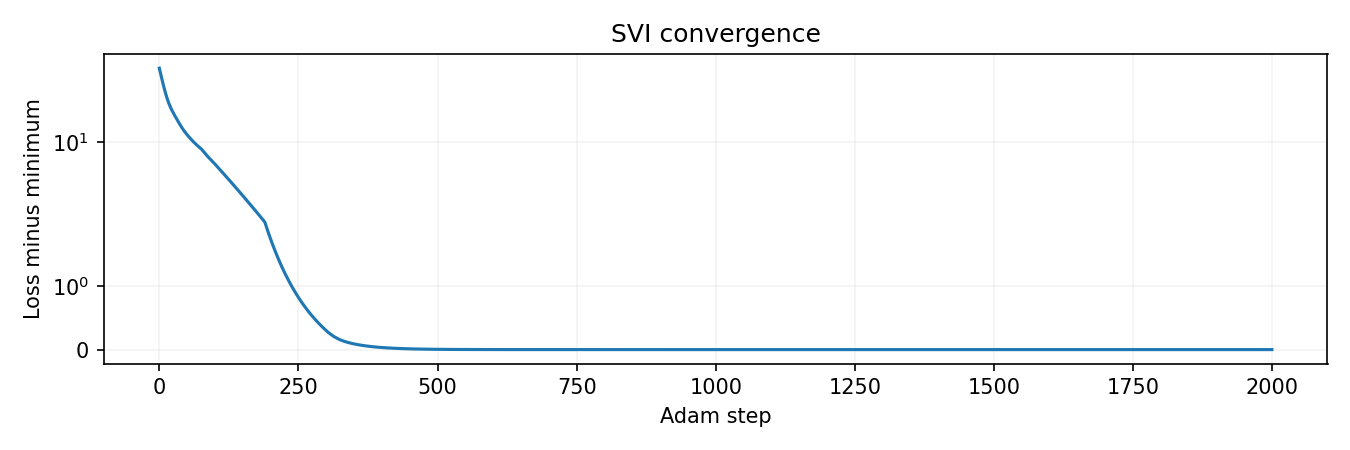

In [4]:
estimate, losses, svi_timing = timed_svi(case, initial=initial, steps=SVI_STEPS, step_size=SVI_STEP_SIZE, seed=0)
svi_timing['first_step_within_0p001_of_final'] = int(np.flatnonzero(np.abs(losses-losses[-1])<.001)[0]+1)
print(json.dumps(svi_timing, indent=2))
map_point = {k: float(v) for k,v in estimate.items()}
display(pd.DataFrame({'parameter': list(map_point), 'MAP_like': list(map_point.values())}))
fig, ax = plt.subplots(figsize=(9,3))
ax.plot(losses - losses.min())
ax.set(yscale='symlog', xlabel='Adam step', ylabel='Loss minus minimum', title='SVI convergence')
fig.tight_layout(); fig.savefig(OUTPUT / 'svi-convergence.png', dpi=150); plt.show()

## Conditional continuum and actual data-space spectrum

Build physical parameters with `single_star_params`, evaluate SpecModel at
observed pixels, then reconstruct the conditional continuum coefficient mean
and covariance. The continuum band below is conditional on this nonlinear
point; it is not a full posterior predictive band. Masked points are omitted
from plotted data/residuals. Large-residual points are marked, not rejected.

{
  "rms": 0.01948331363738061,
  "median": 0.00035351609637546133,
  "robust_scatter": 0.0188472910039007,
  "standardized_rms": 0.9900345147526063,
  "fraction_gt3": 0.005821474773609315,
  "fraction_gt5": 0.0019404915912031048,
  "count_gt3": 9,
  "count_gt5": 3,
  "adjacent_pairs": 1446,
  "lag1_flux": 0.3158284306108434,
  "adjacent_pixel_residual_correlation": 0.33953480376849754,
  "continuum_range": [
    0.9775632982359281,
    1.0413317732536067
  ],
  "continuum_coefficients": [
    [
      1.0117581136308458,
      0.02338096738533384,
      0.0016963883287017545,
      0.008503270123505503,
      -0.0040069662147800954
    ]
  ],
  "continuum_coefficient_std": [
    [
      0.0008158875190594468,
      0.0013518338136834349,
      0.0013186559890865398,
      0.0009723288898291284,
      0.0009511598532027452
    ]
  ]
}


,original_pixel,wavelength_A,flux_residual,standardized
478,634,15324.283914,-0.112419,-6.261872
477,633,15324.169761,-0.096257,-5.403508
1008,1293,15390.666622,-0.104315,-5.279997
1032,1335,15394.289482,-0.079651,-4.186156
851,1117,15374.684644,-0.069639,-3.918370
18,64,15252.799241,0.087023,3.444308
1225,1569,15413.113562,-0.066616,-3.229056
1351,1718,15423.886934,0.065990,3.139442
1035,1338,15394.545428,0.054196,3.017951


2704

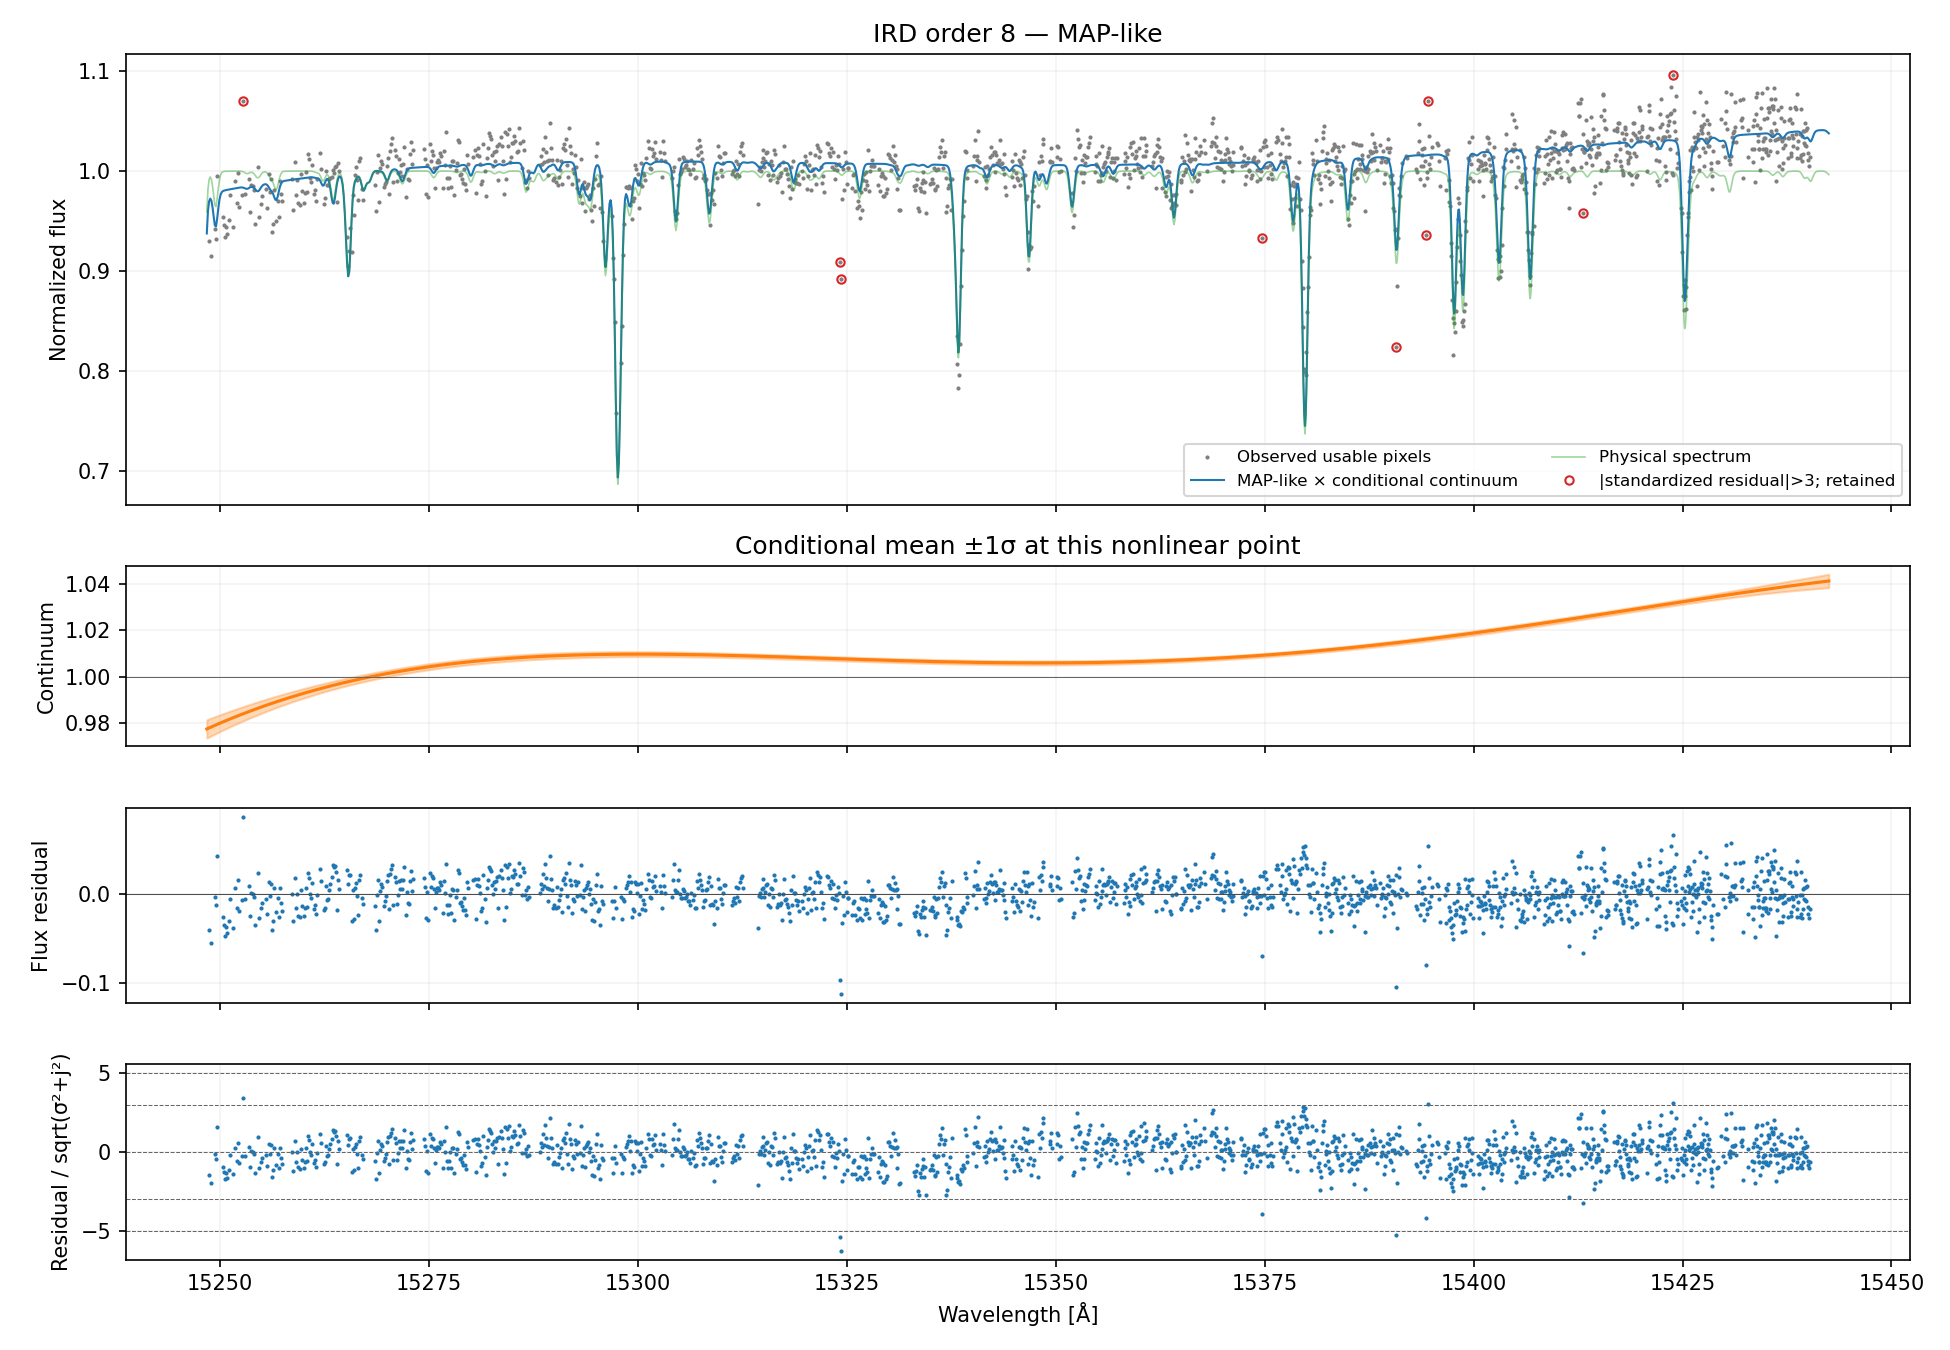

In [5]:
def residual_statistics(fitted, jitter):
    residual = y[good] - fitted[good]
    standardized = residual / np.hypot(error[good], jitter)
    adjacent = np.diff(np.flatnonzero(good)) == 1  # never bridge mask gaps
    stats = dict(rms=float(np.sqrt(np.mean(residual**2))), median=float(np.median(residual)),
        robust_scatter=float(1.4826*np.median(np.abs(residual-np.median(residual)))),
        standardized_rms=float(np.sqrt(np.mean(standardized**2))),
        fraction_gt3=float(np.mean(np.abs(standardized)>3)), fraction_gt5=float(np.mean(np.abs(standardized)>5)),
        count_gt3=int(np.sum(np.abs(standardized)>3)), count_gt5=int(np.sum(np.abs(standardized)>5)),
        adjacent_pairs=int(adjacent.sum()),
        lag1_flux=float(np.corrcoef(residual[:-1][adjacent], residual[1:][adjacent])[0,1]),
        adjacent_pixel_residual_correlation=float(np.corrcoef(
            standardized[:-1][adjacent], standardized[1:][adjacent])[0,1]))
    return residual, standardized, stats


def reconstruct(point, *, gp=False):
    params = single_star_params({n: point[n] for n in specmodel.spectra.grid.axis_names},
        vsini=point['vsini'], vmacro=point['vmacro'], q1=.5, q2=.5,
        rv=point['rv'], resolving_power=70000.)
    physical = specmodel(params, obs.wavelength)
    noise = dict(gp_amplitude=point['gp_amplitude'], gp_scale=point['gp_scale'],
                 gp_solver='auto') if gp else {}
    posterior_function = gp_continuum_posterior if gp else continuum_posterior
    posterior = posterior_function(obs, physical, **noise, basis=basis, degree=4,
        sigma_constant=.1, sigma_continuum=point['sigma_continuum'], jitter=point['jitter'])
    continuum = evaluate_continuum(basis, posterior.mean)
    physical_continuum = apply_continuum(physical, basis, posterior.mean)
    gp_mean = gp_conditional_mean(obs, physical_continuum, **noise,
                                 jitter=point['jitter']) if gp else jnp.zeros_like(physical)
    fitted = physical_continuum + gp_mean
    continuum_std = jnp.sqrt(jnp.einsum('rik,rkl,ril->ri',basis,posterior.covariance,basis))
    residual, standardized, stats = residual_statistics(np.asarray(fitted)[0], point['jitter'])
    stats.update(
        continuum_range=[float(jnp.min(continuum)),float(jnp.max(continuum))],
        continuum_coefficients=np.asarray(posterior.mean).tolist(),
        continuum_coefficient_std=np.sqrt(np.diagonal(np.asarray(posterior.covariance),axis1=-2,axis2=-1)).tolist())
    return dict(params=params, physical=np.asarray(physical)[0], fitted=np.asarray(fitted)[0],
                physical_continuum=np.asarray(physical_continuum)[0], gp_mean=np.asarray(gp_mean)[0],
                continuum=np.asarray(continuum)[0], continuum_std=np.asarray(continuum_std)[0],
                residual=residual, standardized=standardized, stats=stats)

def plot_reconstruction(rec, label, filename):
    fig, axes = plt.subplots(4,1,figsize=(13,9),sharex=True,
                            gridspec_kw={'height_ratios':[3,1.2,1.3,1.3]})
    axes[0].plot(x[good],y[good],'.',ms=2,color='.5',label='Observed usable pixels')
    axes[0].plot(x,rec['fitted'],lw=1,color='C0',label=label+' × conditional continuum')
    axes[0].plot(x,rec['physical'],lw=.8,alpha=.45,color='C2',label='Physical spectrum')
    large=np.abs(rec['standardized'])>3
    axes[0].plot(x[good][large],y[good][large],'o',ms=4,mfc='none',mec='C3',label='|standardized residual|>3; retained')
    axes[0].set(ylabel='Normalized flux',title='IRD order 8 — '+label)
    axes[0].legend(fontsize=8,ncol=2)
    axes[1].plot(x,rec['continuum'],color='C1')
    axes[1].fill_between(x,rec['continuum']-rec['continuum_std'],rec['continuum']+rec['continuum_std'],color='C1',alpha=.3)
    axes[1].axhline(1,color='.4',lw=.5); axes[1].set(ylabel='Continuum',title='Conditional mean ±1σ at this nonlinear point')
    axes[2].plot(x[good],rec['residual'],'.',ms=2); axes[2].axhline(0,color='.3',lw=.5)
    axes[2].set(ylabel='Flux residual')
    axes[3].plot(x[good],rec['standardized'],'.',ms=2)
    for limit in (0,3,-3,5,-5): axes[3].axhline(limit,color='.4',lw=.5,ls='--')
    axes[3].set(ylabel='Residual / sqrt(σ²+j²)',xlabel='Wavelength [Å]')
    for ax in axes: ax.ticklabel_format(useOffset=False,style='plain',axis='x')
    fig.tight_layout(); fig.savefig(OUTPUT / filename,dpi=150); plt.show()

map_rec = reconstruct(map_point)
print(json.dumps(map_rec['stats'],indent=2))
assert np.all(np.isfinite(map_rec['fitted']))
assert np.array_equal(mask_before,np.asarray(obs.mask))
plot_reconstruction(map_rec,'MAP-like','map-spectrum.png')
candidate_table = pd.DataFrame({'original_pixel':np.arange(32,2016)[good], 'wavelength_A':x[good],
     'flux_residual':map_rec['residual'],'standardized':map_rec['standardized']})
display(candidate_table.loc[candidate_table.standardized.abs()>3].sort_values('standardized',key=lambda s:s.abs(),ascending=False).head(12))
candidate_table.to_csv(OUTPUT / 'residuals-map.csv',index=False)
(OUTPUT / 'map-result.json').write_text(json.dumps(dict(environment=environment,data=data_checks,
     svi=svi_timing,map=map_point,residuals=map_rec['stats']),indent=2))

## iid + jitter: short exploratory NUTS

Same `model_single`, same priors, same fixed masks. One chain with 300
warmup and 400 draws, initialized at the MAP-like point, dense mass,
target acceptance 0.9. Warmup includes initialization/JIT; sampling time
includes its first compilation. One short chain cannot establish convergence.
Parameter tables use equal-tail 5–95% intervals. ESS is only a rough diagnostic.

In [6]:
# Inspect the MAP figures before relying on posterior output.
assert map_rec['stats']['rms'] < .06, 'MAP does not look sensible enough for the planned short chain'
mcmc = MCMC(NUTS(probabilistic_model, init_strategy=init_to_value(values=estimate),
    dense_mass=True,target_accept_prob=TARGET_ACCEPT,max_tree_depth=MAX_TREE_DEPTH),
    num_warmup=N_WARMUP,num_samples=N_SAMPLES,num_chains=N_CHAINS,progress_bar=False)
start=perf_counter()
mcmc.warmup(jax.random.PRNGKey(10),obs,specmodel)
jax.block_until_ready(mcmc.last_state)
warmup_seconds=perf_counter()-start
print('Initialization/compile/warmup seconds:',warmup_seconds,flush=True)
start=perf_counter()
mcmc.run(jax.random.PRNGKey(11),obs,specmodel,
         extra_fields=('num_steps','accept_prob','diverging','potential_energy'))
jax.block_until_ready(mcmc.get_samples())
sample_seconds=perf_counter()-start
samples, fields = mcmc.get_samples(), mcmc.get_extra_fields()
assert all(np.all(np.isfinite(v)) for v in samples.values())
diagnostic_summary=chain_summary({n:samples[n][None,:] for n in case.latent_names},prob=.9)
nuts_report=dict(warmup=N_WARMUP,samples=N_SAMPLES,chains=N_CHAINS,compile_initialization_warmup_seconds=warmup_seconds,
    sampling_compile_and_run_seconds=sample_seconds,total_seconds=warmup_seconds+sample_seconds,
    divergences=int(np.sum(fields['diverging'])),mean_acceptance=float(np.mean(fields['accept_prob'])),
    median_leapfrog_steps=float(np.median(fields['num_steps'])),
    max_tree_depth_hits=int(np.sum(np.asarray(fields['num_steps'])>=2**MAX_TREE_DEPTH-1)),
    finite_potential=bool(np.all(np.isfinite(fields['potential_energy']))))
print(json.dumps(nuts_report,indent=2))
rows=[]
for name in case.latent_names:
    lo,median,hi=np.quantile(np.asarray(samples[name]),[.05,.5,.95])
    rows.append(dict(parameter=name,MAP_like=map_point[name],median=float(median),
         lower_90=float(lo),upper_90=float(hi),ESS=float(diagnostic_summary[name]['n_eff']),
         split_Rhat=float(diagnostic_summary[name]['r_hat'])))
comparison=pd.DataFrame(rows)
display(comparison)
comparison.to_csv(OUTPUT / 'parameter-summary.csv',index=False)
np.savez(OUTPUT / 'posterior-samples.npz',**{n:np.asarray(samples[n]) for n in case.latent_names},
         svi_losses=losses,**{'nuts_'+n:np.asarray(v) for n,v in fields.items()})

Initialization/compile/warmup seconds: 25.813998541794717


{
  "warmup": 300,
  "samples": 400,
  "chains": 1,
  "compile_initialization_warmup_seconds": 25.813998541794717,
  "sampling_compile_and_run_seconds": 13.943167416844517,
  "total_seconds": 39.757165958639234,
  "divergences": 0,
  "mean_acceptance": 0.9139418137252335,
  "median_leapfrog_steps": 15.0,
  "max_tree_depth_hits": 0,
  "finite_potential": true
}


,parameter,MAP_like,median,lower_90,upper_90,ESS,split_Rhat
0,teff,5978.928984,5975.892757,5857.152600,6084.042629,317.282273,0.997539
1,logg,3.361444,3.317985,3.116553,3.590767,297.332527,0.998040
2,feh,0.129981,0.130381,0.074227,0.192279,422.233546,0.997837
3,alpha,0.006693,0.005102,0.000673,0.019805,475.517542,0.998436
4,vsini,6.291624,5.255704,2.257814,7.736443,131.770718,1.000507
5,vmacro,7.627906,8.757233,5.710931,9.903847,192.082652,1.009521
6,rv,-23.211541,-23.212771,-23.426158,-22.995786,326.509696,1.003651
7,sigma_continuum,0.015553,0.016594,0.009586,0.033928,242.186649,0.999726
8,jitter,0.006629,0.006566,0.004861,0.007999,424.425484,0.997712


Posterior-median residual diagnostics: {
  "rms": 0.019476882885970104,
  "median": 0.00041396993074177546,
  "robust_scatter": 0.01881617387936343,
  "standardized_rms": 0.9909692457216123,
  "fraction_gt3": 0.005821474773609315,
  "fraction_gt5": 0.0019404915912031048,
  "count_gt3": 9,
  "count_gt5": 3,
  "adjacent_pairs": 1446,
  "lag1_flux": 0.3153785887846213,
  "adjacent_pixel_residual_correlation": 0.33914614971505336,
  "continuum_range": [
    0.9775341650282333,
    1.0413962796303358
  ],
  "continuum_coefficients": [
    [
      1.0117517279300612,
      0.023405641641037804,
      0.0017220378015122618,
      0.0085254156600135,
      -0.004008543402288873
    ]
  ],
  "continuum_coefficient_std": [
    [
      0.0008156072549454596,
      0.0013516989395906702,
      0.0013184900296804582,
      0.0009718526419627846,
      0.000950648438722205
    ]
  ]
}


Adjacent unmasked-pixel residual correlation: 0.33914614971505336


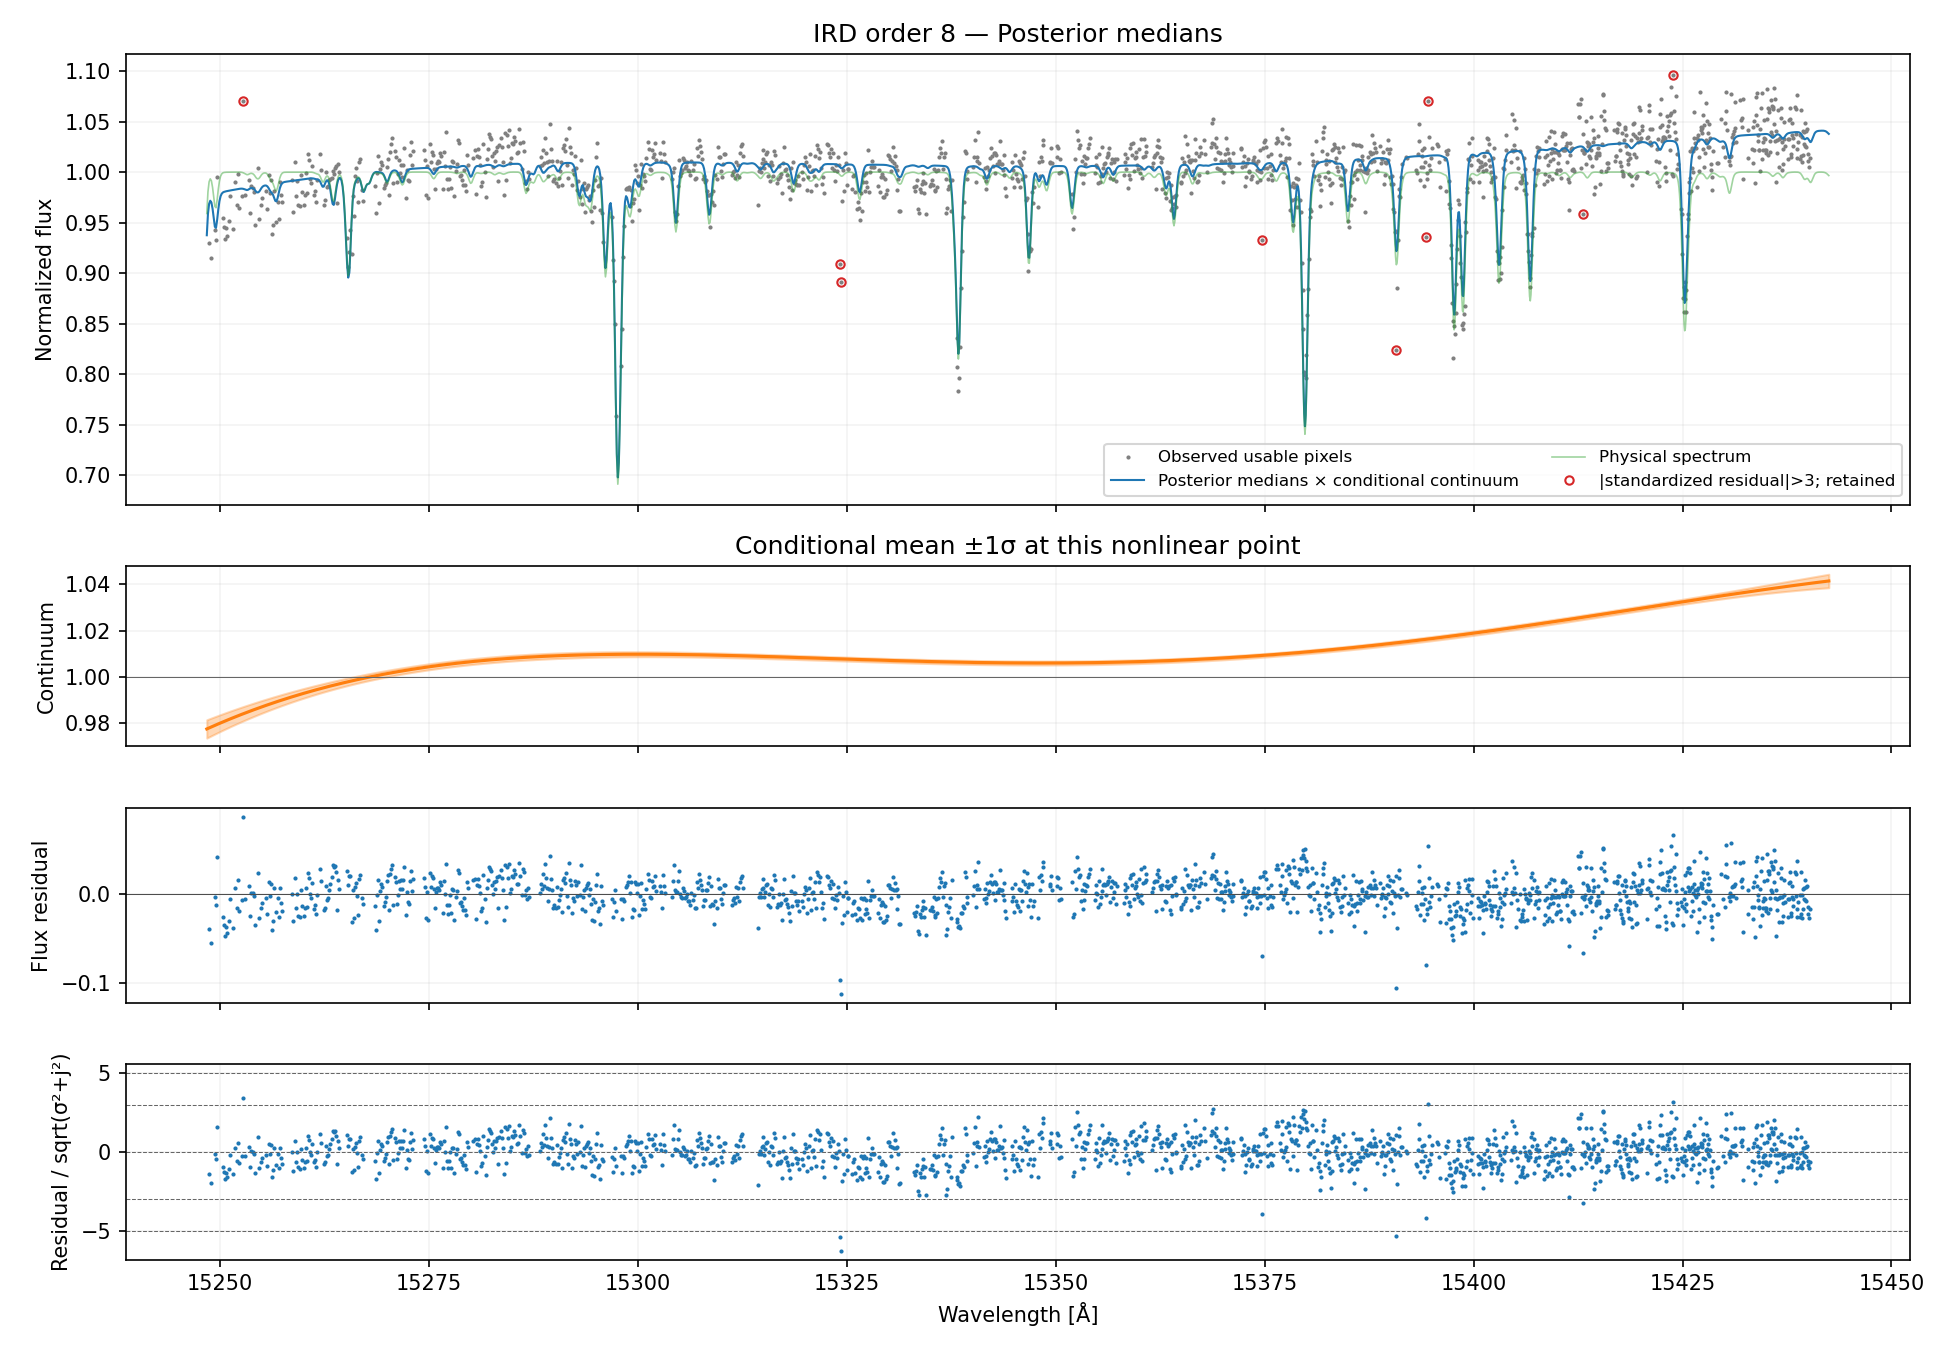

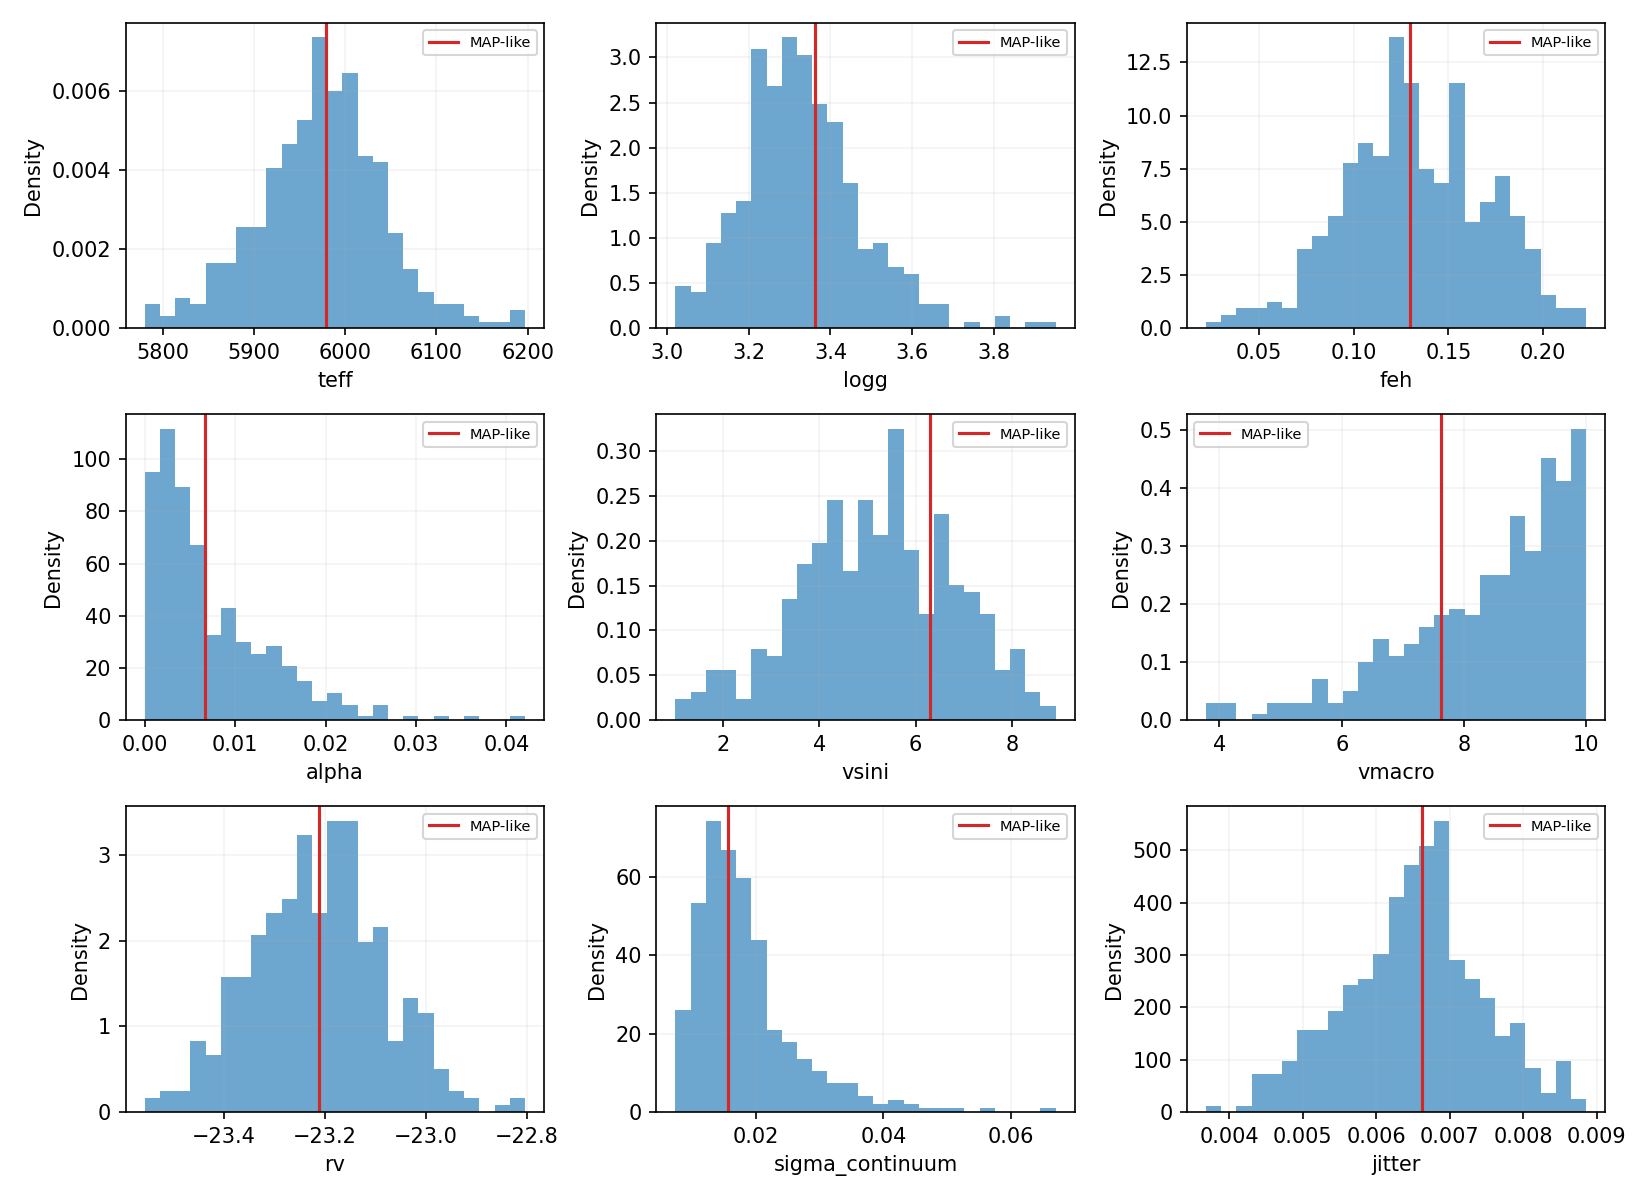

In [7]:
median_point={row['parameter']:row['median'] for row in rows}
median_rec=reconstruct(median_point)
plot_reconstruction(median_rec,'Posterior medians','posterior-median-spectrum.png')
print('Posterior-median residual diagnostics:',json.dumps(median_rec['stats'],indent=2))
fig,axes=plt.subplots(3,3,figsize=(11,8))
for name,ax in zip(case.latent_names,axes.flat):
    ax.hist(np.asarray(samples[name]),bins=25,alpha=.65,density=True)
    ax.axvline(map_point[name],color='C3',label='MAP-like')
    ax.set(xlabel=name,ylabel='Density'); ax.legend(fontsize=7)
fig.tight_layout(); fig.savefig(OUTPUT / 'posteriors.png',dpi=150); plt.show()
# Lag-one correlation uses adjacent usable original pixels, never bridges mask gaps.
pairs=np.diff(np.flatnonzero(good))==1
lag1=float(np.corrcoef(median_rec['standardized'][:-1][pairs],median_rec['standardized'][1:][pairs])[0,1])
median_rec['stats']['adjacent_pixel_residual_correlation']=lag1
print('Adjacent unmasked-pixel residual correlation:',lag1)

## GP + jitter: same physical model and fixed pixels

Only add two positive native noise parameters. Amplitude is a standard deviation
in normalized-flux units; scale is a Matérn-3/2 correlation length in Å.
`gp_amplitude ~ HalfNormal(0.02)` is comparable to the existing residual/noise scale.
`gp_scale ~ LogNormal(log(0.5 Å), 0.8)` has a prior central 90% range about
0.13–1.86 Å: several pixels and plausible line-width scales, far shorter than
this 194 Å order. It does not strongly favor the white limit or whole-order
correlations. The prior was chosen from the sampling/width scales, not fit outcomes.
R=70000 gives instrumental FWHM ≈0.220 Å; 5–10 km/s corresponds to ≈0.26–0.51 Å.
GP scale is not a FWHM. All original stellar, continuum and jitter priors remain identical.


In [8]:
sampling_info = dict(pixel_spacing_A=np.quantile(np.diff(x), [0,.5,1]).tolist(),
    span_A=float(x[-1]-x[0]), instrumental_FWHM_A=float(np.median(x)/70000.),
    gp_scale_prior_90_A=np.exp(np.log(.5)+np.array([-1,1])*1.644854*.8).tolist())
print(json.dumps(sampling_info, indent=2))
gp_priors = {**case.priors, 'gp_amplitude':dist.HalfNormal(.02),
             'gp_scale':dist.LogNormal(np.log(.5), .8), 'gp_solver':'auto'}
gp_initial = {**initial, 'gp_amplitude':.015, 'gp_scale':.5}
gp_model = partial(model_single, **gp_priors)
gp_lp, gp_trace = log_density(gp_model, (obs,specmodel), {}, gp_initial)
gp_latent_names = tuple(n for n,s in gp_trace.items() if s['type']=='sample' and not s['is_observed'])
assert np.isfinite(gp_lp)
assert set(gp_latent_names) == set(case.latent_names) | {'gp_amplitude','gp_scale'}
print('GP sampled:', gp_latent_names, 'initial joint log density:', float(gp_lp))

{
  "pixel_spacing_A": [
    0.05625031729869079,
    0.09831826226036355,
    0.13775855352832878
  ],
  "span_A": 194.09579818694874,
  "instrumental_FWHM_A": 0.2195096000768144,
  "gp_scale_prior_90_A": [
    0.13411865569839396,
    1.86402106924036
  ]
}


GP sampled: ('teff', 'logg', 'feh', 'alpha', 'vsini', 'vmacro', 'rv', 'sigma_continuum', 'jitter', 'gp_amplitude', 'gp_scale') initial joint log density: 3856.9069581099775


### GP MAP-like SVI

Same AutoLaplaceApproximation/Adam/Trace_ELBO and 2000 steps at 0.01 as iid.
The existing timing helper traces Observation as an argument; GP masks must be
fixed instead. This small notebook version captures the concrete Observation
in the update scan and keeps SpecModel/library arrays dynamic. It uses the
normal public model API. Timing separates initialization, scan compilation and
optimization; the summed segments are rough wall times, not a controlled benchmark.


{
  "initialize_seconds": 2.0423399172723293,
  "compile_seconds": 1.8155916249379516,
  "optimization_seconds": 11.396312832832336,
  "steps": 2000,
  "initial_loss": -3847.671674207568,
  "final_loss": -3956.0142838715715,
  "last_100_loss_range": 0.005053693379522883
}


,parameter,GP_MAP_like
0,teff,6001.428826
1,logg,3.552061
2,feh,0.115814
3,alpha,0.018009
4,vsini,6.573885
5,vmacro,6.985271
6,rv,-23.220187
7,sigma_continuum,0.016031
8,jitter,0.001171
9,gp_amplitude,0.009806


GP MAP residual RMS: 0.015775821937619453


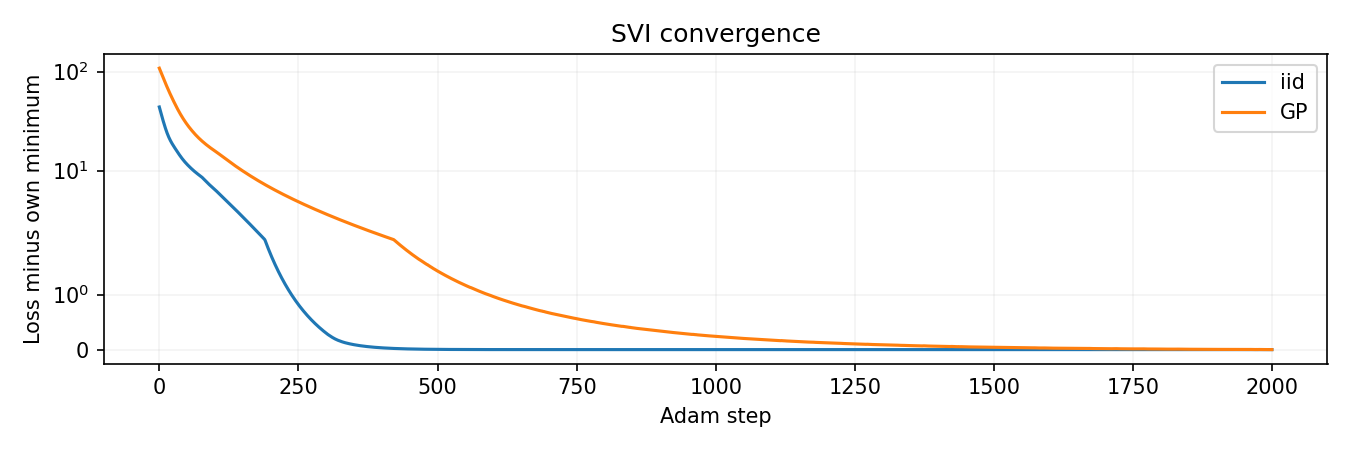

In [9]:
def fixed_mask_svi(model, initial, latent_names):
    guide = AutoLaplaceApproximation(model, init_loc_fn=init_to_value(values=initial))
    svi = SVI(model, guide, numpyro.optim.Adam(SVI_STEP_SIZE), Trace_ELBO())
    start = perf_counter()
    state = svi.init(jax.random.PRNGKey(0), obs, specmodel)
    jax.block_until_ready(state)
    initialize_seconds = perf_counter()-start
    def run(state, sm):
        return jax.lax.scan(lambda state,_:svi.update(state,obs,sm), state, None, length=SVI_STEPS)
    start = perf_counter()
    compiled = jax.jit(run).lower(state, specmodel).compile()
    compile_seconds = perf_counter()-start
    start = perf_counter()
    final, losses = jax.block_until_ready(compiled(state, specmodel))
    optimization_seconds = perf_counter()-start
    estimate = {n:v for n,v in guide.median(svi.get_params(final)).items() if n in latent_names}
    losses = np.asarray(losses)
    assert np.all(np.isfinite(losses))
    timing = dict(initialize_seconds=initialize_seconds, compile_seconds=compile_seconds,
        optimization_seconds=optimization_seconds, steps=SVI_STEPS,
        initial_loss=float(losses[0]), final_loss=float(losses[-1]),
        last_100_loss_range=float(np.ptp(losses[-100:])))
    return estimate, losses, timing

gp_estimate, gp_losses, gp_svi_timing = fixed_mask_svi(gp_model, gp_initial, gp_latent_names)
gp_map_point = {n:float(v) for n,v in gp_estimate.items()}
print(json.dumps(gp_svi_timing, indent=2))
display(pd.DataFrame({'parameter':list(gp_map_point), 'GP_MAP_like':list(gp_map_point.values())}))
fig, ax = plt.subplots(figsize=(9,3))
for label, history in [('iid',losses),('GP',gp_losses)]:
    ax.plot(history-history.min(), label=label)
ax.set(yscale='symlog', xlabel='Adam step', ylabel='Loss minus own minimum', title='SVI convergence')
ax.legend(); fig.tight_layout(); fig.savefig(OUTPUT/'iid-gp-svi.png', dpi=150); plt.show()
gp_map_rec = reconstruct(gp_map_point, gp=True)
assert np.all(np.isfinite(gp_map_rec['fitted'])) and gp_map_rec['stats']['rms'] < .06
np.testing.assert_array_equal(mask_before, np.asarray(obs.mask))
print('GP MAP residual RMS:', gp_map_rec['stats']['rms'])

### GP short exploratory NUTS

Use the same one-chain 300 warmup / 400 draws, dense mass, target acceptance 0.9,
maximum tree depth 8, and random seeds as iid, initialized at its own SVI location.
Ordinary MCMC arguments and fixed masks; no `jit_model_args=True`.
Warmup includes initialization/compilation; sampling includes its scan compilation.
ESS and split R-hat from one short chain are screening diagnostics, not proof of convergence.


In [10]:
gp_mcmc = MCMC(NUTS(gp_model, init_strategy=init_to_value(values=gp_estimate),
    dense_mass=True, target_accept_prob=TARGET_ACCEPT, max_tree_depth=MAX_TREE_DEPTH),
    num_warmup=N_WARMUP,num_samples=N_SAMPLES,num_chains=N_CHAINS,progress_bar=False)
start = perf_counter()
gp_mcmc.warmup(jax.random.PRNGKey(10), obs, specmodel)
jax.block_until_ready(gp_mcmc.last_state)
gp_warmup_seconds = perf_counter()-start
print('GP initialization/compile/warmup seconds:', gp_warmup_seconds, flush=True)
start = perf_counter()
gp_mcmc.run(jax.random.PRNGKey(11),obs,specmodel,
    extra_fields=('num_steps','accept_prob','diverging','potential_energy'))
jax.block_until_ready(gp_mcmc.get_samples())
gp_sample_seconds = perf_counter()-start
gp_samples, gp_fields = gp_mcmc.get_samples(), gp_mcmc.get_extra_fields()
assert all(np.all(np.isfinite(v)) for v in gp_samples.values())
assert 'model_flux' not in gp_samples  # no per-draw model or GP predictions
summary_gp = chain_summary({n:gp_samples[n][None,:] for n in gp_latent_names}, prob=.9)
gp_nuts_report = dict(warmup=N_WARMUP,samples=N_SAMPLES,chains=N_CHAINS,
    compile_initialization_warmup_seconds=gp_warmup_seconds,
    sampling_compile_and_run_seconds=gp_sample_seconds,total_seconds=gp_warmup_seconds+gp_sample_seconds,
    divergences=int(np.sum(gp_fields['diverging'])), mean_acceptance=float(np.mean(gp_fields['accept_prob'])),
    median_leapfrog_steps=float(np.median(gp_fields['num_steps'])),
    max_tree_depth_hits=int(np.sum(np.asarray(gp_fields['num_steps'])>=2**MAX_TREE_DEPTH-1)),
    finite_potential=bool(np.all(np.isfinite(gp_fields['potential_energy']))))
print(json.dumps(gp_nuts_report, indent=2))
gp_rows = []
for name in gp_latent_names:
    lo,med,hi = np.quantile(np.asarray(gp_samples[name]),[.05,.5,.95])
    gp_rows.append(dict(parameter=name,MAP_like=gp_map_point[name],median=float(med),
        lower_90=float(lo),upper_90=float(hi),ESS=float(summary_gp[name]['n_eff']),
        split_Rhat=float(summary_gp[name]['r_hat'])))
gp_comparison = pd.DataFrame(gp_rows)
display(gp_comparison)
gp_comparison.to_csv(OUTPUT/'gp-parameter-summary.csv',index=False)
np.savez(OUTPUT/'gp-posterior-samples.npz',**{n:np.asarray(gp_samples[n]) for n in gp_latent_names},
    svi_losses=gp_losses,**{'nuts_'+n:np.asarray(v) for n,v in gp_fields.items()})

GP initialization/compile/warmup seconds: 113.36477783275768


{
  "warmup": 300,
  "samples": 400,
  "chains": 1,
  "compile_initialization_warmup_seconds": 113.36477783275768,
  "sampling_compile_and_run_seconds": 63.37721391720697,
  "total_seconds": 176.74199174996465,
  "divergences": 0,
  "mean_acceptance": 0.9141808641815299,
  "median_leapfrog_steps": 31.0,
  "max_tree_depth_hits": 0,
  "finite_potential": true
}


,parameter,MAP_like,median,lower_90,upper_90,ESS,split_Rhat
0,teff,6001.428826,6068.618192,5872.939139,6348.843667,154.203323,0.998601
1,logg,3.552061,3.641293,3.160695,4.218201,148.889358,0.997506
2,feh,0.115814,0.151128,0.056848,0.247273,241.877820,0.999684
3,alpha,0.018009,0.011131,0.000788,0.048198,524.643811,0.997505
4,vsini,6.573885,5.554014,0.987723,7.960180,75.238000,1.013959
5,vmacro,6.985271,8.263143,4.686107,9.856198,129.457348,1.021089
6,rv,-23.220187,-23.224998,-23.470345,-22.987386,387.418348,0.998345
7,sigma_continuum,0.016031,0.017469,0.009567,0.035790,231.283737,1.010081
8,jitter,0.001171,0.000736,0.000085,0.002051,200.500513,0.997612
9,gp_amplitude,0.009806,0.009925,0.008736,0.011083,344.594504,1.006477


### GP posterior corner (`corner.py`)

All 11 sampled parameters from the same 400 GP NUTS draws, including continuum
scale, additive jitter and the two GP hyperparameters. Fixed R and limb-darkening
parameters are omitted. Titles show medians with equal-tail 5–95% bounds, matching
the summary table. Pairwise contours are smoothed visualization of this short
chain, not evidence of convergence. Requires the optional plotting package `corner`.


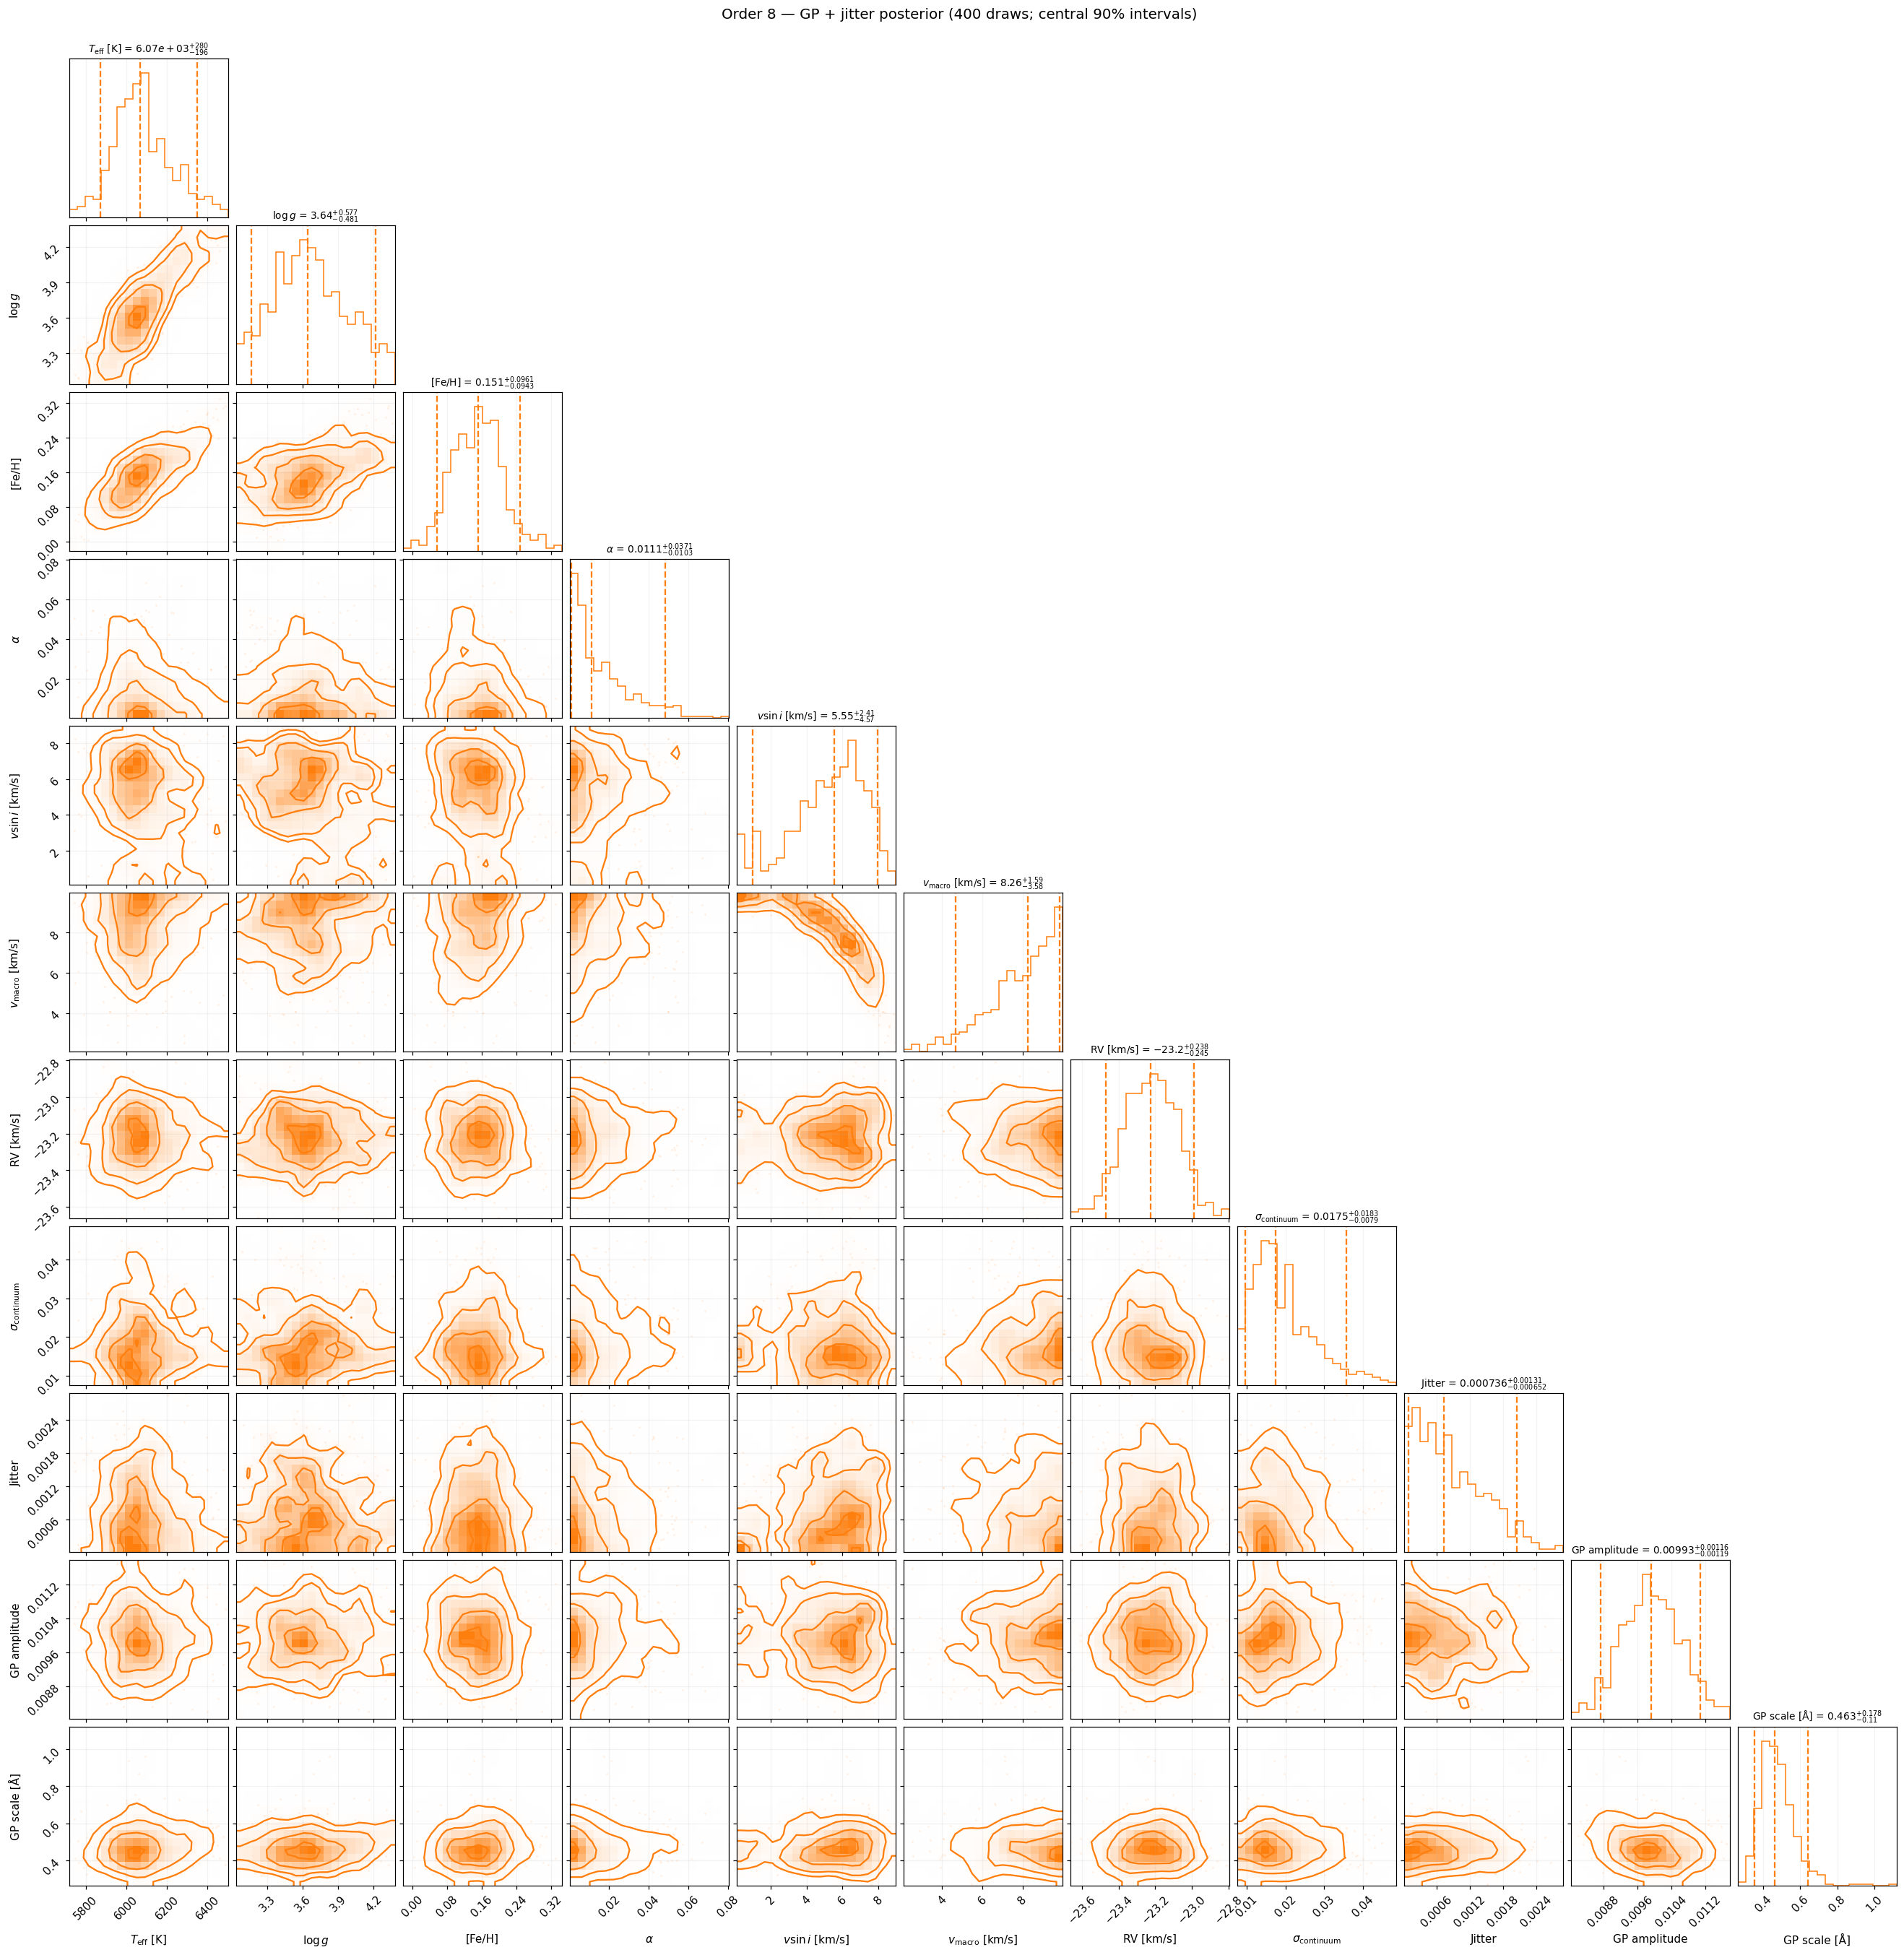

In [17]:
import corner

gp_corner_names = ('teff','logg','feh','alpha','vsini','vmacro','rv',
                   'sigma_continuum','jitter','gp_amplitude','gp_scale')
gp_corner_labels = [r'$T_{\mathrm{eff}}$ [K]', r'$\log g$', '[Fe/H]', r'$\alpha$',
    r'$v\sin i$ [km/s]', r'$v_{\mathrm{macro}}$ [km/s]', 'RV [km/s]',
    r'$\sigma_{\mathrm{continuum}}$', 'Jitter', 'GP amplitude', 'GP scale [Å]']
gp_corner_draws = np.column_stack([np.asarray(gp_samples[name]) for name in gp_corner_names])
assert gp_corner_draws.shape == (N_SAMPLES, len(gp_corner_names))
assert np.all(np.isfinite(gp_corner_draws))
fig = corner.corner(gp_corner_draws, labels=gp_corner_labels, bins=20,
    quantiles=[.05,.5,.95], title_quantiles=[.05,.5,.95], show_titles=True,
    title_fmt='.3g', smooth=1., color='C1', plot_datapoints=True,
    label_kwargs={'fontsize':10}, title_kwargs={'fontsize':9})
fig.suptitle('Order 8 — GP + jitter posterior (400 draws; central 90% intervals)',
             fontsize=13, y=1.01)
fig.savefig(OUTPUT/'gp-posterior-corner.png', dpi=110, bbox_inches='tight')
plt.show()


## iid vs GP at posterior medians

At each model's nonlinear posterior medians, recover the conditional continuum
mean using the same covariance as its likelihood. For GP, first recover
`gp_continuum_posterior`, multiply the physical spectrum by that continuum,
then add `gp_conditional_mean` conditioned on the remaining residuals.
This is a point reconstruction, not a posterior-averaged prediction/band.

All statistics use the same 1546 usable pixels. Standardized residuals divide by
`sqrt(uncertainty² + jitter²)` in **both** cases, after subtracting the GP mean
for GP. GP amplitude is not added to this denominator. These are in-sample
conditional residuals; reduced RMS/outlier counts do not by themselves validate
predictive calibration. Lag-1 correlations use only adjacent original pixels
that are both usable; report flux and standardized versions separately.


In [11]:
gp_median_point = {r['parameter']:r['median'] for r in gp_rows}
gp_median_rec = reconstruct(gp_median_point, gp=True)
assert np.all(np.isfinite(gp_median_rec['fitted']))
np.testing.assert_array_equal(mask_before, np.asarray(obs.mask))
posterior_comparison = comparison[['parameter','median','lower_90','upper_90']].merge(
    gp_comparison[['parameter','median','lower_90','upper_90']], on='parameter',how='outer',suffixes=('_iid','_GP'))
posterior_comparison['GP_minus_iid'] = posterior_comparison.median_GP-posterior_comparison.median_iid
display(posterior_comparison)
metrics = ['rms','robust_scatter','standardized_rms','count_gt3','count_gt5',
           'lag1_flux','adjacent_pixel_residual_correlation','adjacent_pairs']
residual_comparison = pd.DataFrame({label:{n:rec['stats'][n] for n in metrics}
    for label,rec in [('iid',median_rec),('GP',gp_median_rec)]}).T
display(residual_comparison)
def inference_row(label, svi, nuts, table):
    return dict(model=label,SVI_init_s=svi['initialize_seconds'],SVI_compile_s=svi['compile_seconds'],
        SVI_optimize_s=svi['optimization_seconds'],
        SVI_total_s=sum(svi[k] for k in ('initialize_seconds','compile_seconds','optimization_seconds')),
        NUTS_warmup_compile_s=nuts['compile_initialization_warmup_seconds'],
        NUTS_sampling_compile_s=nuts['sampling_compile_and_run_seconds'],NUTS_total_s=nuts['total_seconds'],
        divergences=nuts['divergences'],acceptance=nuts['mean_acceptance'],
        min_ESS=table.ESS.min(),max_split_Rhat=table.split_Rhat.max(),
        median_steps=nuts['median_leapfrog_steps'],depth_hits=nuts['max_tree_depth_hits'])
inference_comparison = pd.DataFrame([inference_row('iid',svi_timing,nuts_report,comparison),
    inference_row('GP',gp_svi_timing,gp_nuts_report,gp_comparison)]).set_index('model')
display(inference_comparison.T)
posterior_comparison.to_csv(OUTPUT/'iid-gp-parameters.csv',index=False)
residual_comparison.to_csv(OUTPUT/'iid-gp-residuals.csv')
inference_comparison.to_csv(OUTPUT/'iid-gp-inference.csv')
comparison_result = dict(environment=environment,data=data_checks,gp_priors={'amplitude':'HalfNormal(.02)',
    'scale':'LogNormal(log(.5 Angstrom),.8)'},sampling=sampling_info,
    iid=dict(svi=svi_timing,nuts=nuts_report,parameters=rows,residuals=median_rec['stats']),
    GP=dict(svi=gp_svi_timing,nuts=gp_nuts_report,parameters=gp_rows,residuals=gp_median_rec['stats']))
(OUTPUT/'iid-gp-comparison.json').write_text(json.dumps(comparison_result,indent=2));

,parameter,median_iid,lower_90_iid,upper_90_iid,median_GP,lower_90_GP,upper_90_GP,GP_minus_iid
0,alpha,0.005102,0.000673,0.019805,0.011131,0.000788,0.048198,0.006029
1,feh,0.130381,0.074227,0.192279,0.151128,0.056848,0.247273,0.020747
2,gp_amplitude,NaN,NaN,NaN,0.009925,0.008736,0.011083,NaN
3,gp_scale,NaN,NaN,NaN,0.462746,0.352472,0.640781,NaN
4,jitter,0.006566,0.004861,0.007999,0.000736,0.000085,0.002051,-0.005829
5,logg,3.317985,3.116553,3.590767,3.641293,3.160695,4.218201,0.323307
6,rv,-23.212771,-23.426158,-22.995786,-23.224998,-23.470345,-22.987386,-0.012228
7,sigma_continuum,0.016594,0.009586,0.033928,0.017469,0.009567,0.035790,0.000875
8,teff,5975.892757,5857.152600,6084.042629,6068.618192,5872.939139,6348.843667,92.725434
9,vmacro,8.757233,5.710931,9.903847,8.263143,4.686107,9.856198,-0.494090


,rms,robust_scatter,standardized_rms,count_gt3,count_gt5,lag1_flux,adjacent_pixel_residual_correlation,adjacent_pairs
iid,0.019477,0.018816,0.990969,9.0,3.0,0.315379,0.339146,1446.0
GP,0.015771,0.014837,0.837885,8.0,1.0,-0.007094,-0.003048,1446.0


model,iid,GP
SVI_init_s,5.908929,2.042340
SVI_compile_s,1.303413,1.815592
SVI_optimize_s,3.304086,11.396313
SVI_total_s,10.516428,15.254244
NUTS_warmup_compile_s,25.813999,113.364778
NUTS_sampling_compile_s,13.943167,63.377214
NUTS_total_s,39.757166,176.741992
divergences,0.000000,0.000000
acceptance,0.913942,0.914181
min_ESS,131.770718,75.238000


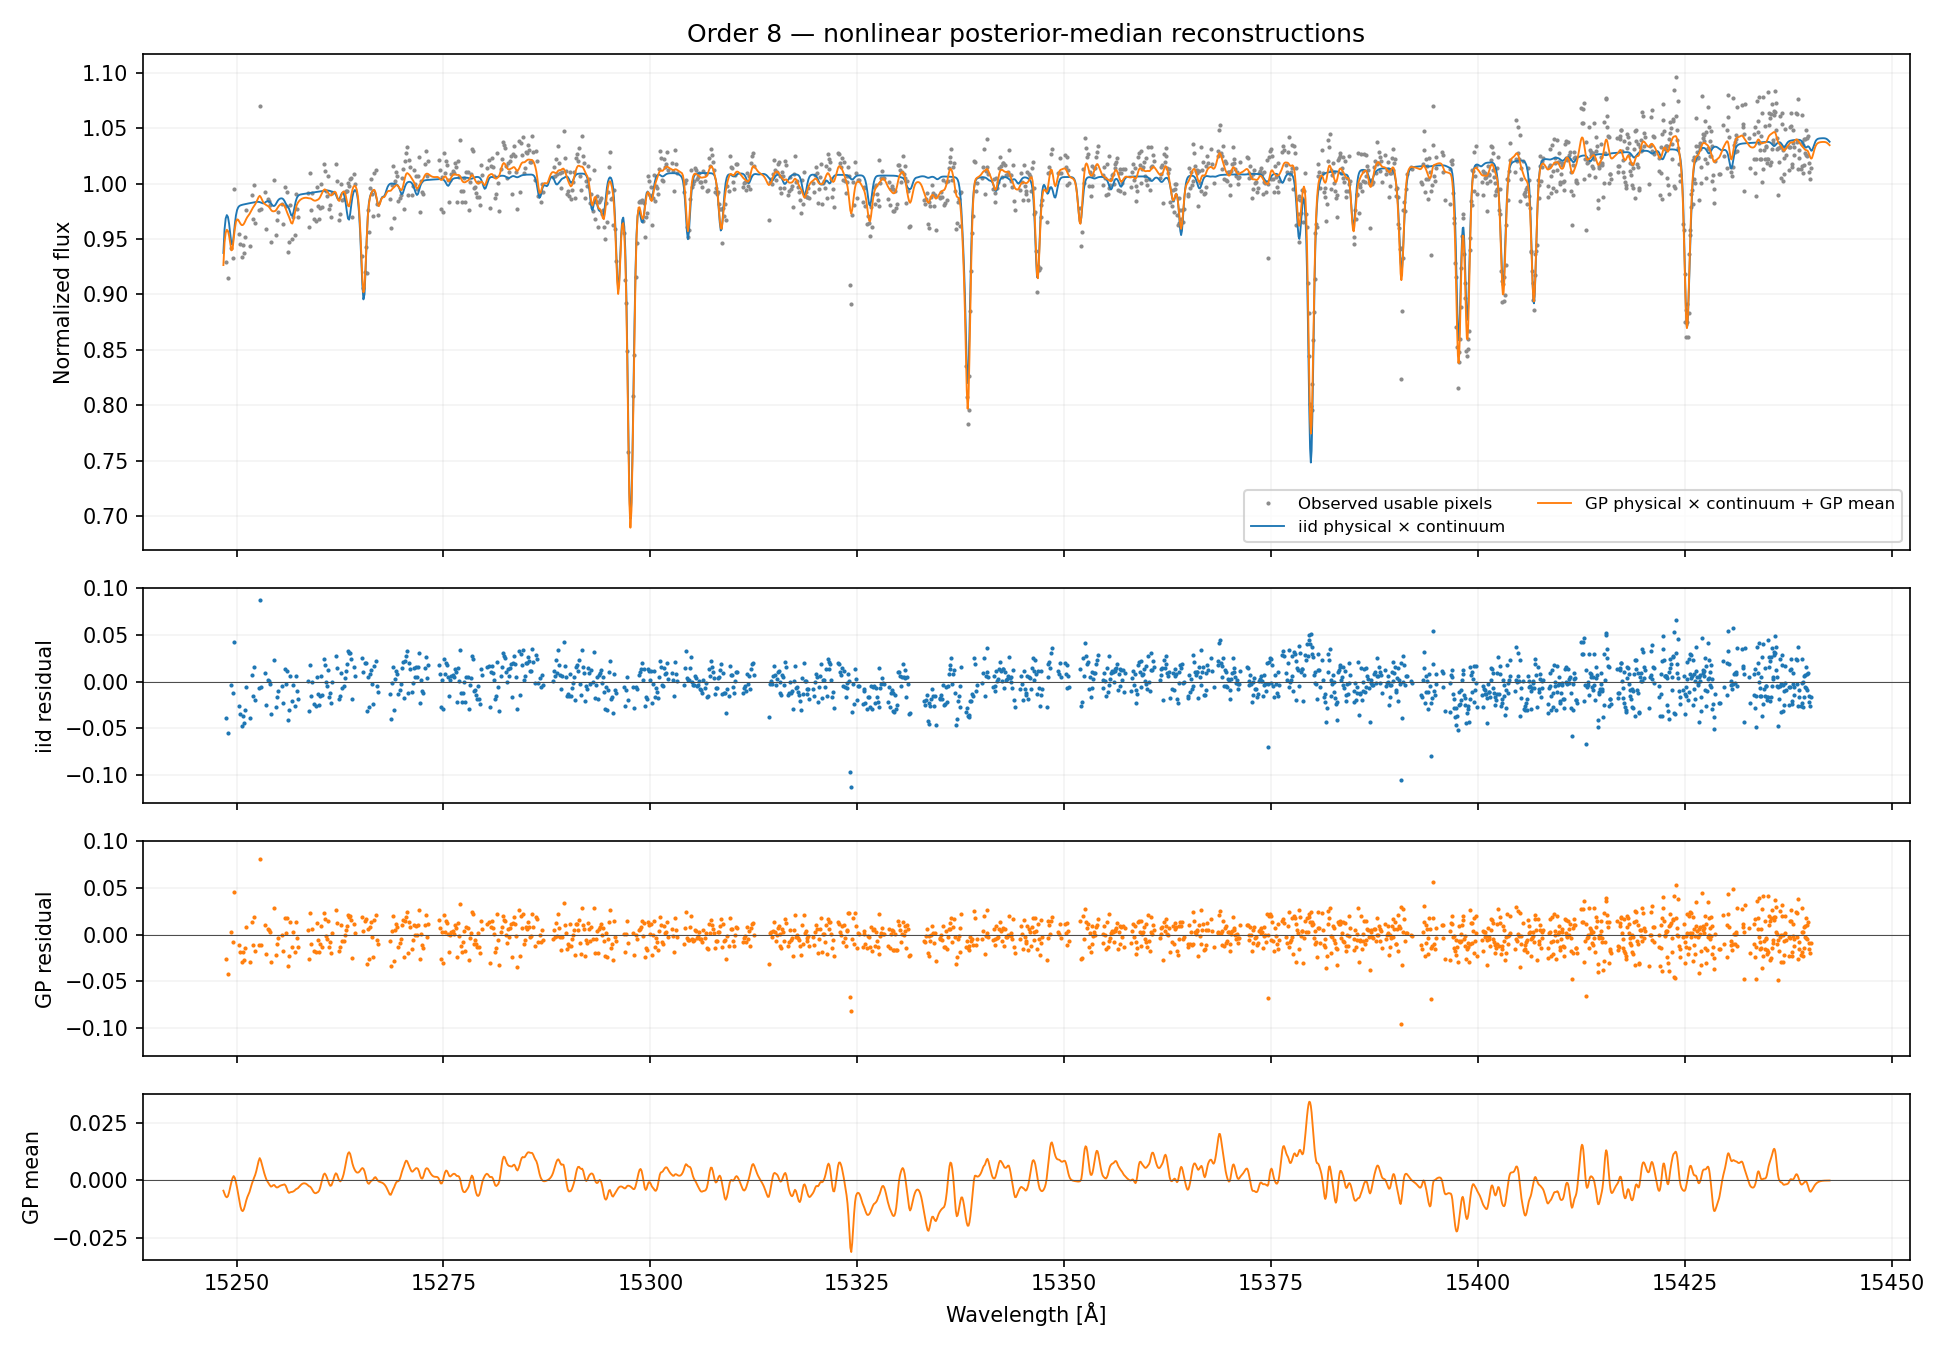

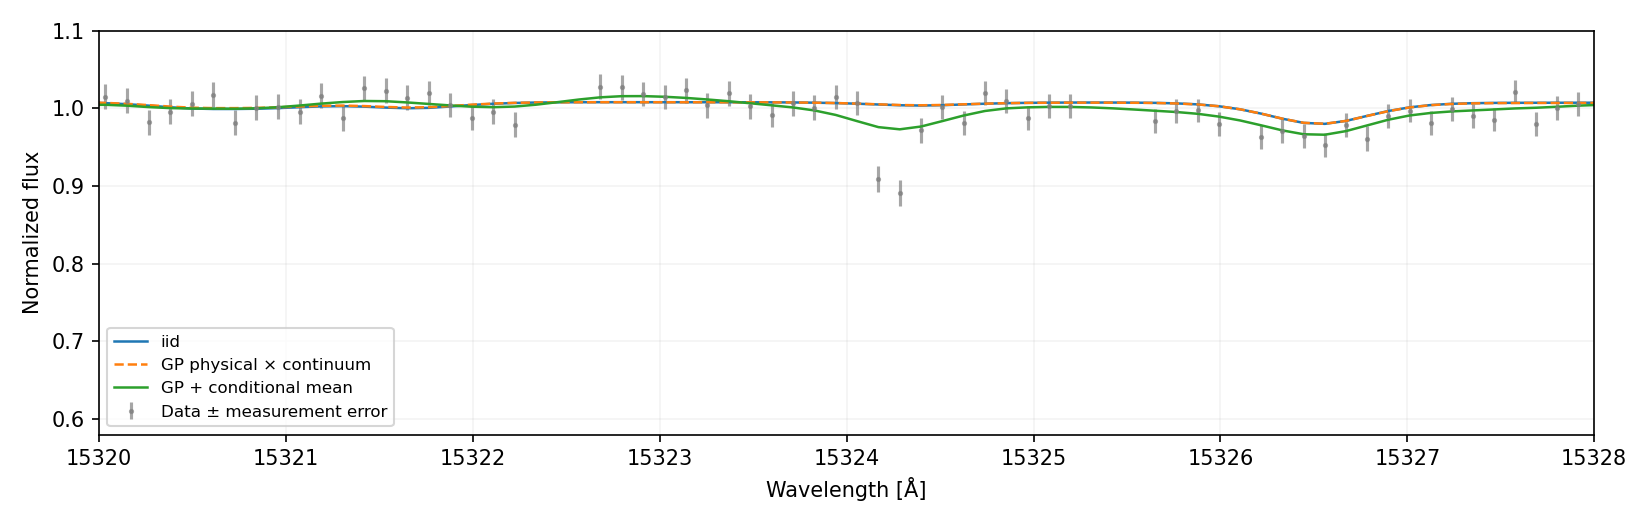

In [12]:
fig, axes = plt.subplots(4,1,figsize=(13,9),sharex=True,
    gridspec_kw={'height_ratios':[3,1.3,1.3,1]})
axes[0].plot(x[good],y[good],'.',ms=2,color='.55',label='Observed usable pixels')
axes[0].plot(x,median_rec['fitted'],lw=.9,label='iid physical × continuum')
axes[0].plot(x,gp_median_rec['fitted'],lw=.9,label='GP physical × continuum + GP mean')
axes[0].set(ylabel='Normalized flux',title='Order 8 — nonlinear posterior-median reconstructions')
axes[0].legend(fontsize=8,ncol=2)
for ax,rec,label,color in [(axes[1],median_rec,'iid','C0'),(axes[2],gp_median_rec,'GP','C1')]:
    ax.plot(x[good],rec['residual'],'.',ms=2,color=color)
    ax.axhline(0,color='.3',lw=.5); ax.set(ylabel=label+' residual',ylim=(-.13,.10))
axes[3].plot(x,gp_median_rec['gp_mean'],color='C1',lw=.9)
axes[3].axhline(0,color='.3',lw=.5)
axes[3].set(ylabel='GP mean',xlabel='Wavelength [Å]')
for ax in axes: ax.ticklabel_format(useOffset=False,style='plain',axis='x')
fig.tight_layout(); fig.savefig(OUTPUT/'iid-gp-order8.png',dpi=150); plt.show()
# Zoom on the negative mismatch feature; show the continuum-only GP physical model too.
fig, ax = plt.subplots(figsize=(11,3.5))
ax.errorbar(x[good],y[good],yerr=error[good],fmt='.',ms=3,color='.5',alpha=.7,label='Data ± measurement error')
ax.plot(x,median_rec['fitted'],label='iid',lw=1.2)
ax.plot(x,gp_median_rec['physical_continuum'],'--',label='GP physical × continuum',lw=1.2)
ax.plot(x,gp_median_rec['fitted'],label='GP + conditional mean',lw=1.2)
ax.set(xlim=(15320,15328),ylim=(.58,1.10),xlabel='Wavelength [Å]',ylabel='Normalized flux')
ax.ticklabel_format(useOffset=False,style='plain',axis='x'); ax.legend(fontsize=8)
fig.tight_layout(); fig.savefig(OUTPUT/'iid-gp-feature.png',dpi=150); plt.show()

## Appendix: read-only legacy comparison

Saved two-order legacy posterior plot: Teff median **6282 K**, logg **4.33**,
[Fe/H] **0.17**, alpha **0.01**, vsini **7.40 km/s**, vmacro (zeta) **4.84 km/s**.
These numbers are transcribed from saved corner-plot titles, not regenerated
fits. Old RV is only stored in scaled form (order8 median≈0.55): combining the
saved initial −23.588 and its ±5 range gives approximately **−23.1 km/s**;
the exact old physical RV/interval is unavailable. R was fixed at 70000.
Its saved physical continuum rises roughly from 0.99 to 1.04; exact coefficients
and an order-specific numeric residual statistic were not saved here.
Old GP median lna≈−4.47 (amplitude≈0.0114), lnc≈0.50 (scale≈1.65 Å),
lnsigma≈−8.60 (white jitter≈0.000184). Old jitter excluded the GP contribution,
so it is not directly comparable to the iid branch’s white-noise-only jitter.

Important intentional differences: one order vs two; fixed limb darkening vs
sampled; degree-4 marginalized continuum vs fitted linear norm/slope; original
masks only vs iteratively clipped masks; the iid branch has no GP; no conditional logg cap.
The external grid used for the saved fit is unavailable, so exact historical
grid identity cannot be established. Supplied characterization inputs are used.
Saved plots are displayed unchanged; no CCF is calculated.

**Saved legacy order-8 fit (blue: physical+linear continuum; orange: +GP)**

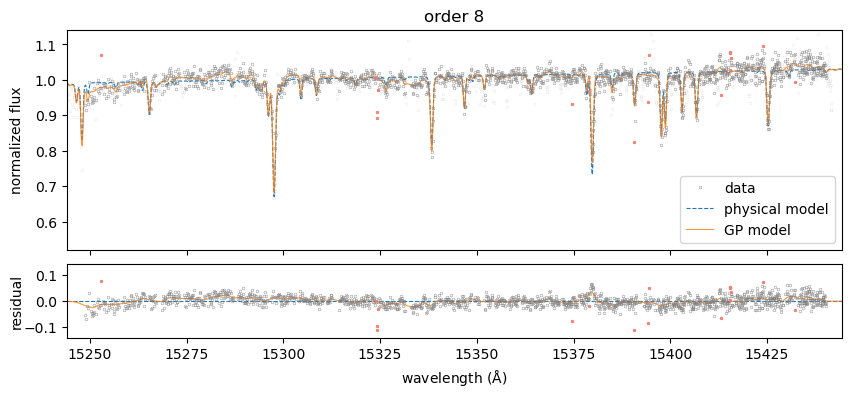

**Saved legacy two-order posterior corner plot**

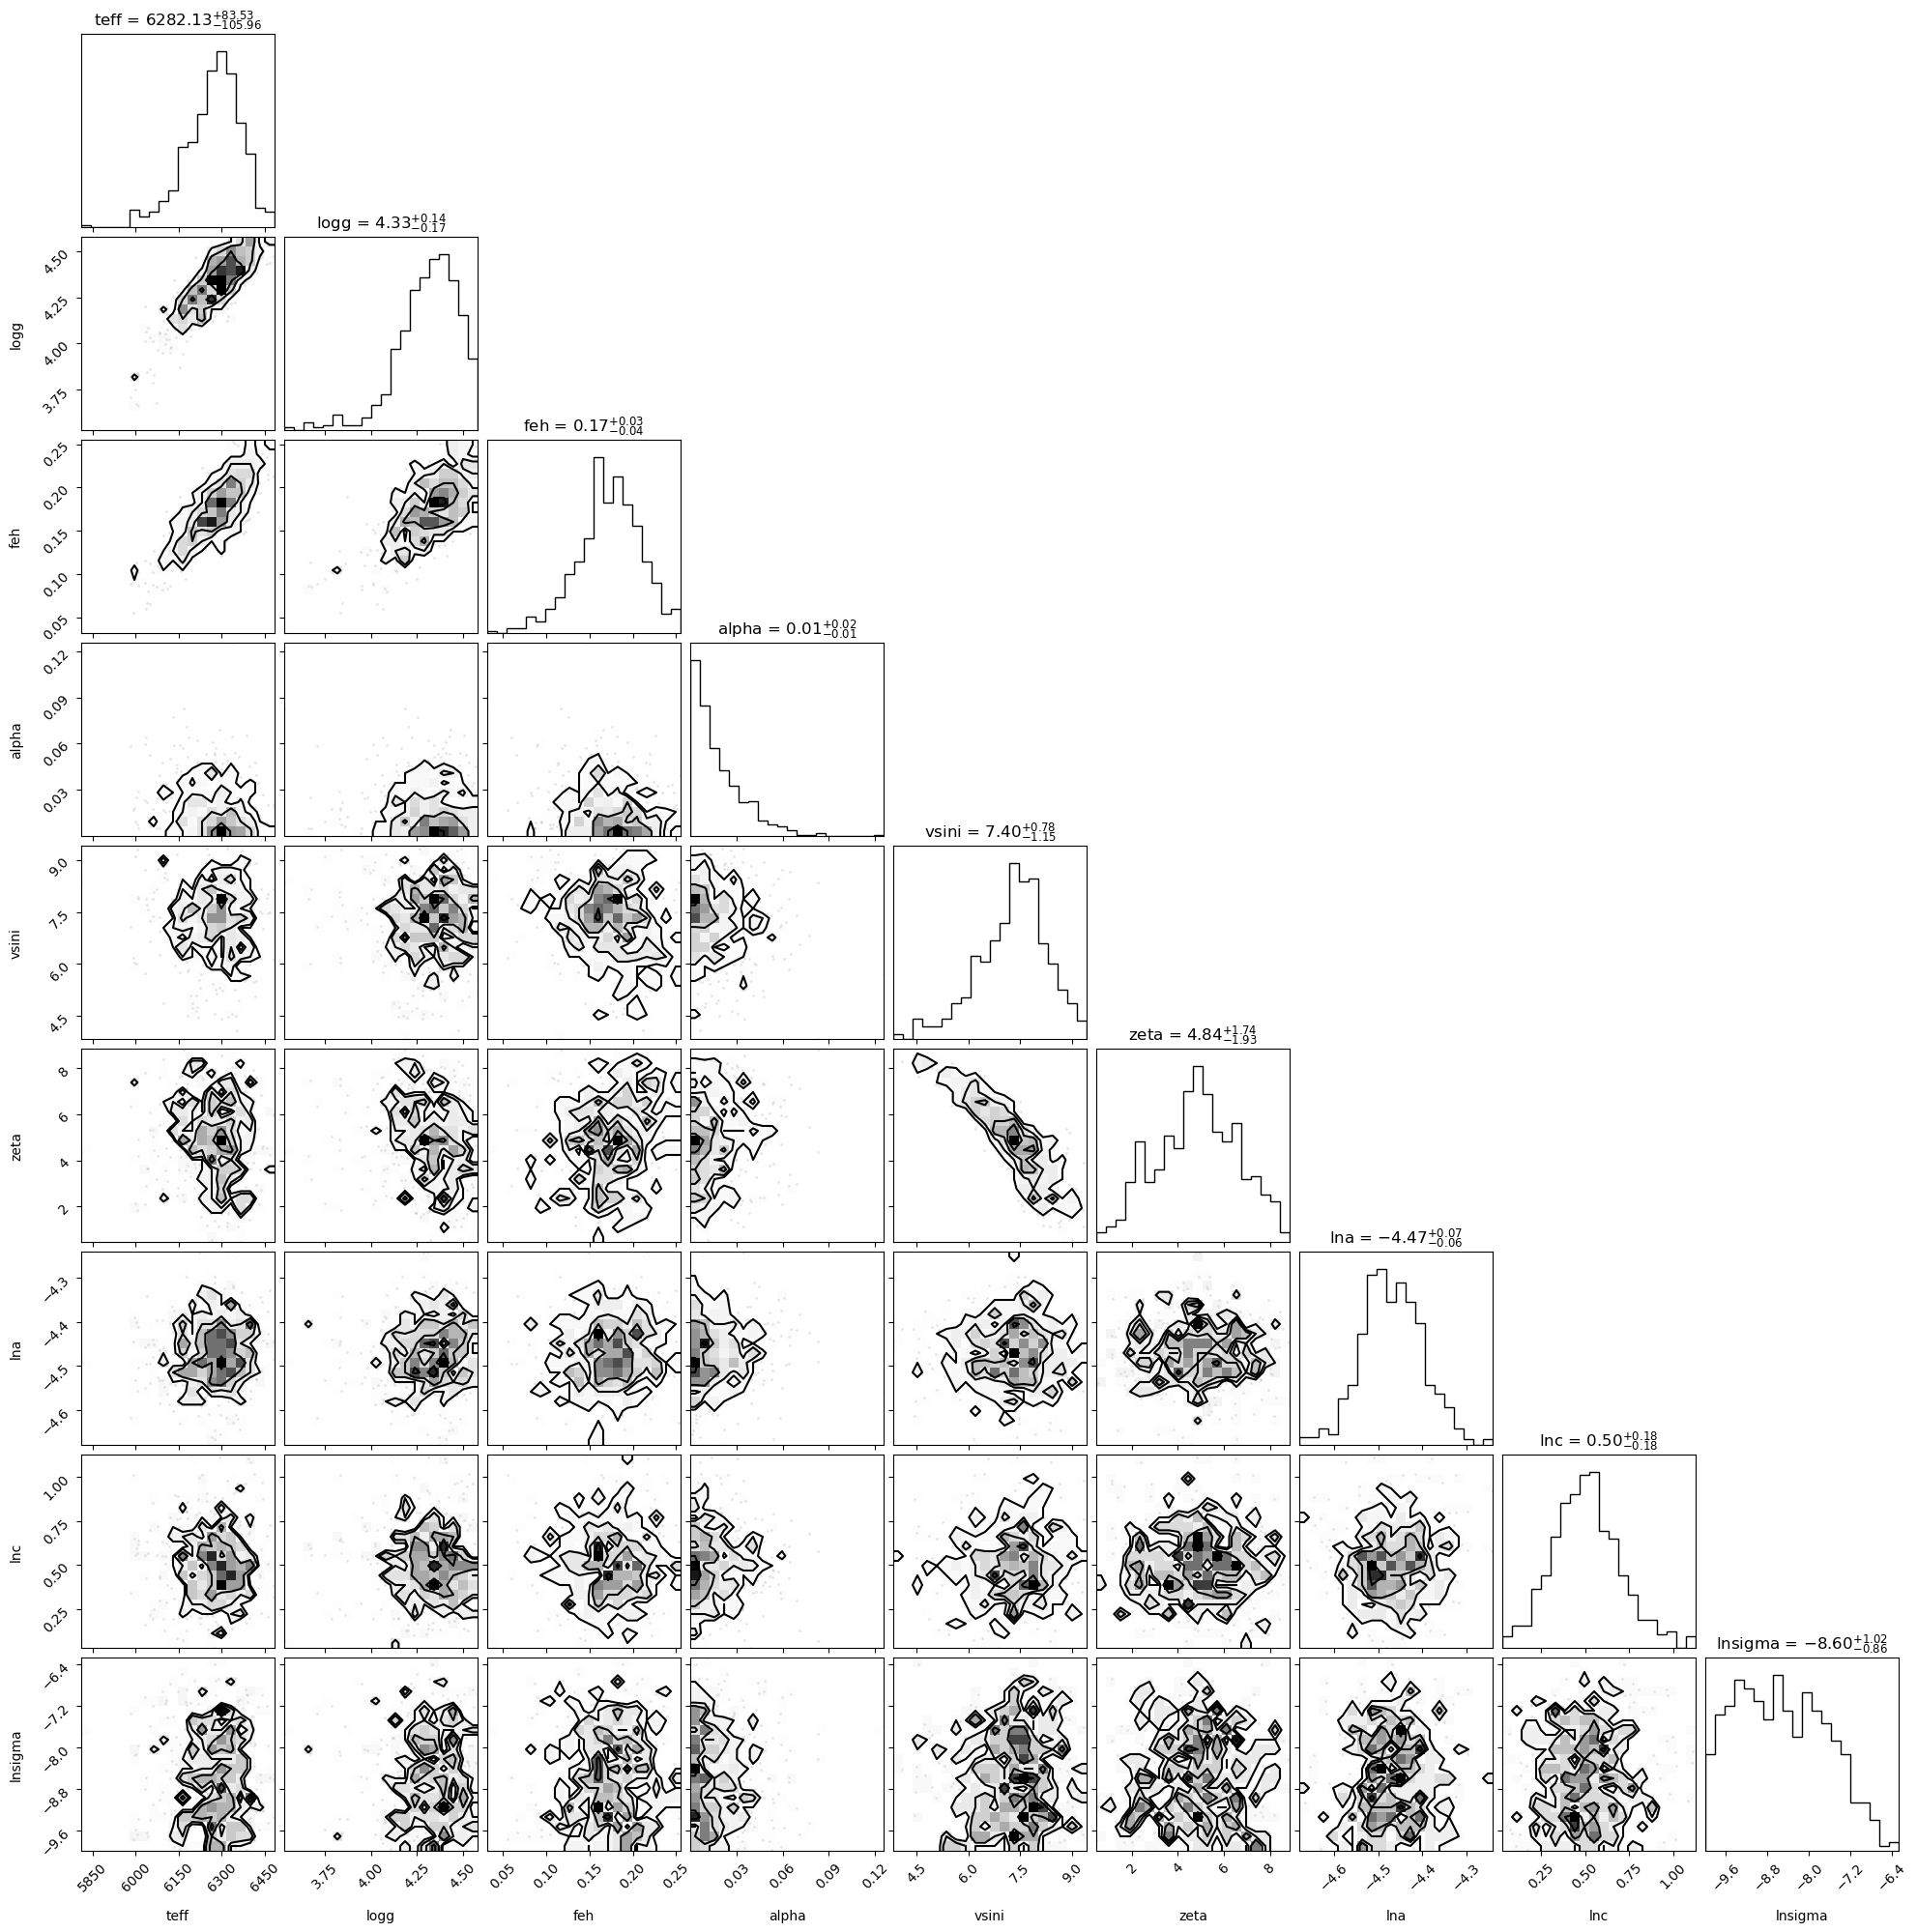

,parameter,new_MAP_like,new_median,legacy_median_approx
0,teff,5978.928984,5975.892757,6282.13
1,logg,3.361444,3.317985,4.33
2,feh,0.129981,0.130381,0.17
3,alpha,0.006693,0.005102,0.01
4,vsini,6.291624,5.255704,7.40
5,vmacro,7.627906,8.757233,4.84
6,rv,-23.211541,-23.212771,-23.10


In [13]:
import nbformat, base64
old_notebook=nbformat.read(REFERENCE / 'examples/spectrum_fitting_example.ipynb',as_version=4)
for cell_index,title in ((27,'Saved legacy order-8 fit (blue: physical+linear continuum; orange: +GP)'),
                         (28,'Saved legacy two-order posterior corner plot')):
    png=next(o['data']['image/png'] for o in old_notebook.cells[cell_index].outputs if 'image/png' in o.get('data',{}))
    display(Markdown('**'+title+'**'))
    display(Image(data=base64.b64decode(png),width=900))
legacy_medians=dict(teff=6282.13,logg=4.33,feh=.17,alpha=.01,vsini=7.40,vmacro=4.84,rv=-23.1)
display(pd.DataFrame([{'parameter':n,'new_MAP_like':map_point[n],'new_median':median_point[n],
    'legacy_median_approx':v} for n,v in legacy_medians.items()]))

### Is the physical forward model responsible for any differences?

At our same MAP-like physical point, compare against frozen numerical source
using the supplied native Coelho file, unit continuum, and zero dilution.
Extracting only the enclosing atmosphere cell keeps old JIT constants small;
no atmosphere values are changed and no new regression oracle is written.
Frozen jaxspec uses its old 5000-sample log grid with endpoints removed;
our prepared grid uses 1 km/s. Report the resulting physical-flux difference,
rather than attributing a changed inferred parameter to the forward model.

Same-point physical forward comparison: {'rms': 0.0001363428372533045, 'max_absolute': 0.002219866168104878, 'legacy_dv_kms': 0.8207558582425634, 'prepared_dv_kms': 1.0}
Local output: /Users/k_masuda/Dropbox/repos/jaxstar/benchmark-results/real-order8-exploration


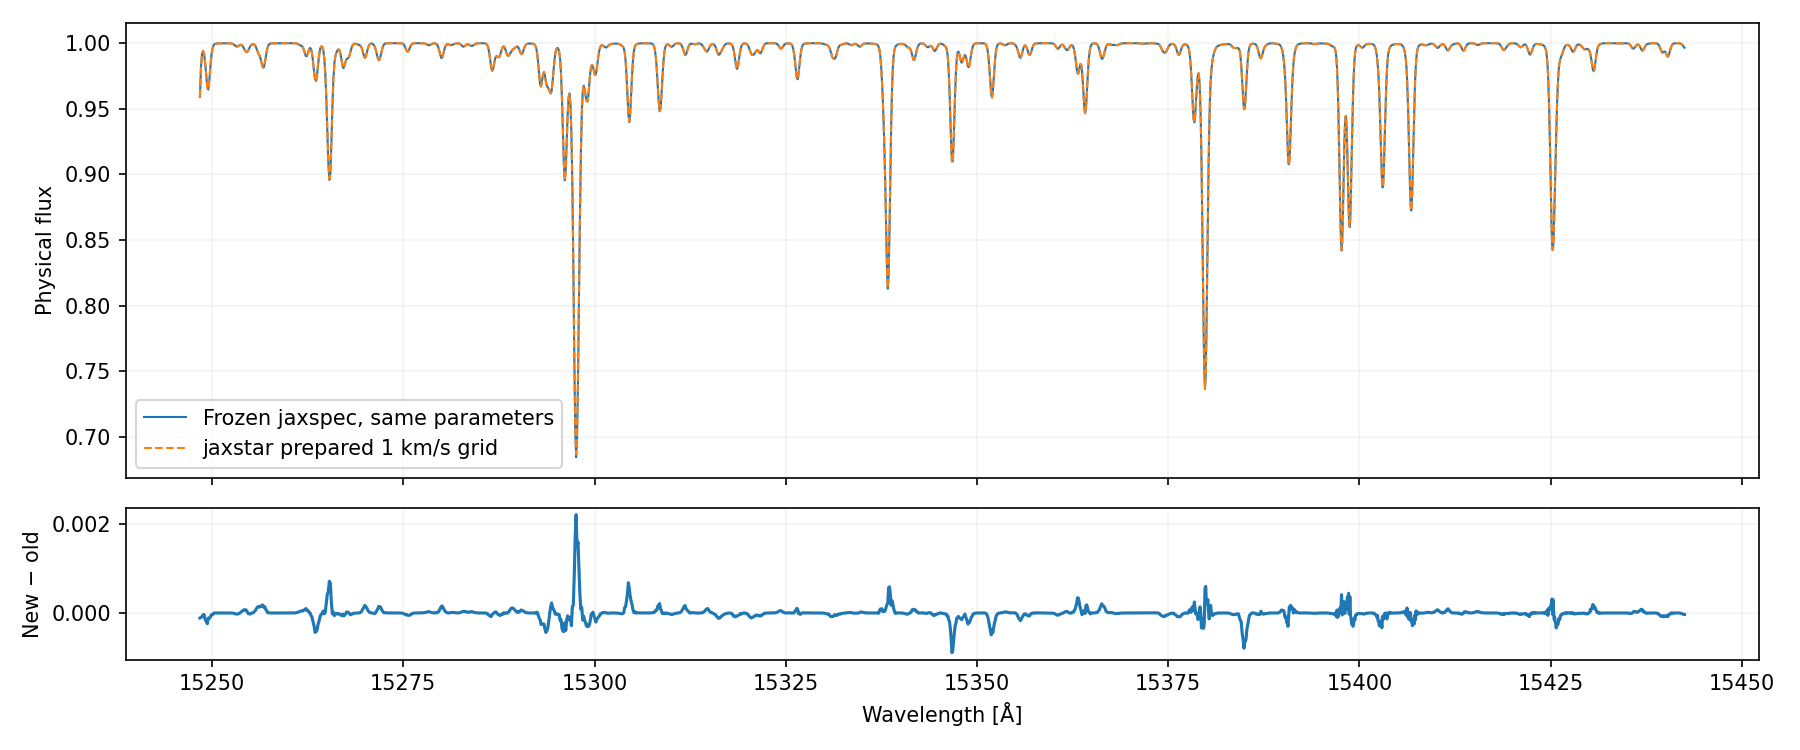

In [14]:
from _specmodel_reference import frozen_modules, verify_reference
verify_reference(REFERENCE)
modules=frozen_modules(REFERENCE)
source_path=REFERENCE / 'characterization/sample_grid_coelho/15239-15449_normed.npz'
axes_keys={'teff':'tgrid','logg':'ggrid','feh':'fgrid','alpha':'agrid'}
with np.load(source_path,allow_pickle=False) as source:
    selected=[]; local={}
    for name,key in axes_keys.items():
        a=source[key]; upper=int(np.clip(np.searchsorted(a,map_point[name],side='right'),1,len(a)-1))
        indices=np.array([upper-1,upper]); selected.append(indices); local[key]=a[indices]
    local['wavgrid']=source['wavgrid'].copy()
    local['flux']=source['flux'][np.ix_(*selected,np.arange(len(source['wavgrid'])))].copy()
local_path=OUTPUT / 'legacy-enclosing-cell.npz'
np.savez(local_path,**local)
old_grid=modules.specgrid.SpecGrid([local_path])
old_model=modules.specmodel.SpecModel(old_grid,np.asarray(obs.wavelength),np.asarray(obs.flux),
        np.asarray(obs.uncertainty),np.asarray(obs.mask),vmax=50.)
component=map_rec['params']['components'][0]
old_params={**component['atmosphere'],'vsini':map_point['vsini'],'zeta':map_point['vmacro'],
    'u1':component['broadening']['u1'],'u2':component['broadening']['u2'],
    'rv':jnp.array([map_point['rv']]),'wavres':jnp.array([70000.]),
    'norm':jnp.ones(1),'slope':jnp.zeros(1),'dilution':0.}
legacy_physical=np.asarray(old_model.fluxmodel_multiorder(old_params))[0]
difference=map_rec['physical']-legacy_physical
forward_comparison=dict(rms=float(np.sqrt(np.mean(difference**2))),max_absolute=float(np.max(np.abs(difference))),
    legacy_dv_kms=float(old_model.dlogwav[0]*299792.458),prepared_dv_kms=1.)
print('Same-point physical forward comparison:',forward_comparison)
fig,axes=plt.subplots(2,1,figsize=(12,5),sharex=True,gridspec_kw={'height_ratios':[3,1]})
axes[0].plot(x,legacy_physical,label='Frozen jaxspec, same parameters',lw=1)
axes[0].plot(x,map_rec['physical'],'--',label='jaxstar prepared 1 km/s grid',lw=1)
axes[0].legend(); axes[0].set(ylabel='Physical flux')
axes[1].plot(x,difference); axes[1].set(ylabel='New − old',xlabel='Wavelength [Å]')
for ax in axes: ax.ticklabel_format(useOffset=False,style='plain',axis='x')
fig.tight_layout(); fig.savefig(OUTPUT / 'same-point-legacy-comparison.png',dpi=150); plt.show()
np.testing.assert_array_equal(mask_before,np.asarray(obs.mask))
result=dict(environment=environment,data=data_checks,priors={'R_fixed':70000,'q1_fixed':.5,'q2_fixed':.5,
    'logg_bounds':[3,5],'sigma_constant_fixed':.1,'sigma_continuum':'LogNormal(log(.03),.7)','jitter':'HalfNormal(.01)',
    'rv_initial':RV_INITIAL,'rv_bounds':[RV_INITIAL-5,RV_INITIAL+5],
    'vsini_bounds':[0,LEGACY_BROAD_LIMIT],'vmacro_bounds':[0,10]},
    svi=svi_timing,map=map_point,map_residuals=map_rec['stats'],nuts=nuts_report,
    parameters=rows,posterior_median_residuals=median_rec['stats'],forward_comparison=forward_comparison,
    limitations=['One order; one short chain','This legacy control uses the iid point; no outlier rejection','Conditional continuum at nonlinear point',
                 'Unknown wavelength medium retained','Historical external grid unavailable'])
(OUTPUT / 'result.json').write_text(json.dumps(result,indent=2))
print('Local output:',OUTPUT)

### Matched wavelength-sampling control

The 1 km/s artifact differs numerically from the old 0.820756 km/s working grid.
For an additional control, prepare the same native node spectra once on the
old log samples using the existing resampling API. At identical atmosphere,
broadening and RV, this should remove the sampling difference. Nothing in
SpecModel or the stored main artifact is changed.

In [15]:
from dataclasses import replace
from jaxstar.grid import Field, RectilinearGrid
from jaxstar.specfit import load_coelho, resample_spectral_grid, SpecModel
local_library=load_coelho(local_path,regions=(8,),flux_kind='normalized',wavelength_medium='unknown')
matched_complete=resample_spectral_grid(local_library,pixels=len(local['wavgrid']))
field=matched_complete.grid.field('flux')
matched_grid=RectilinearGrid(axes={a:matched_complete.grid.axis(a) for a in matched_complete.grid.axis_names},
    fields={'flux':Field(field.values[...,1:-1],field.dims,payload_dims=field.payload_dims)})
matched_library=replace(matched_complete,grid=matched_grid,wavelength=matched_complete.wavelength[:,1:-1])
matched_physical=np.asarray(SpecModel(matched_library,vmax=50.)(map_rec['params'],obs.wavelength))[0]
matched_difference=matched_physical-legacy_physical
matched_control=dict(rms=float(np.sqrt(np.mean(matched_difference**2))),
                     max_absolute=float(np.max(np.abs(matched_difference))))
print('Same parameters, matched sampling:',matched_control)
assert matched_control['max_absolute'] < 1e-7, 'Investigate actual physical-forward mismatch before changing core'
forward_comparison['matched_sampling_control']=matched_control
result['forward_comparison']=forward_comparison
(OUTPUT / 'result.json').write_text(json.dumps(result,indent=2))

Same parameters, matched sampling: {'rms': 1.0107213846216616e-10, 'max_absolute': 7.76564035298577e-10}


7484

### Continuum-degree sensitivity; same model, priors and pixels

Use the packaged `model_single` again with degree 1 (a linear multiplicative
continuum) to check whether polynomial curvature alone is driving the atmospheric
shift. This remains a marginalized Gaussian continuum, not the legacy fitted
Uniform norm/slope prior or its GP likelihood. It is only a MAP-like sensitivity
check, not another posterior run. The main result above remains degree 4.

In [16]:
from types import SimpleNamespace
linear_priors={**case.priors,'degree':1,'basis':chebyshev_basis(obs.wavelength,degree=1)}
linear_case=SimpleNamespace(observation=obs,specmodel=specmodel,priors=linear_priors,
                           latent_names=case.latent_names)
linear_estimate,linear_losses,linear_timing=timed_svi(linear_case,initial=map_point,
    steps=2000,step_size=.01,seed=0)
linear_point={k:float(v) for k,v in linear_estimate.items()}
display(pd.DataFrame([{'parameter':n,'degree4_MAP_like':map_point[n],
                      'degree1_MAP_like':linear_point[n]} for n in map_point]))
params=single_star_params({n:linear_point[n] for n in specmodel.spectra.grid.axis_names},
    vsini=linear_point['vsini'],vmacro=linear_point['vmacro'],q1=.5,q2=.5,
    rv=linear_point['rv'],resolving_power=70000.)
physical=specmodel(params,obs.wavelength)
post=continuum_posterior(obs,physical,basis=linear_priors['basis'],degree=1,
    sigma_constant=.1,sigma_continuum=linear_point['sigma_continuum'],jitter=linear_point['jitter'])
fitted=np.asarray(apply_continuum(physical,linear_priors['basis'],post.mean))[0]
linear_rms=float(np.sqrt(np.mean((y[good]-fitted[good])**2)))
print('Degree-1 residual RMS:',linear_rms)
broad_path=OUTPUT / 'broad-gravity-result.json'
if broad_path.exists():
    broad_gravity=json.loads(broad_path.read_text())
    display(pd.DataFrame([{'parameter':n,'gravity_3to5_median':median_point[n],
        'gravity_1to5_median':next(r['median'] for r in broad_gravity['parameters'] if r['parameter']==n)}
        for n in ('teff','logg','feh','vsini','vmacro','rv')]))
    print('The broader-gravity run is preserved in broad-gravity-executed.ipynb; it is not an additional claimed stellar solution.')
else:
    print('Optional earlier gravity-sensitivity artifacts absent; main inference remains reproducible.')
result['sensitivity']={'degree1_MAP_like':linear_point,'degree1_residual_rms':linear_rms,
    'degree1_svi':linear_timing,'broad_gravity_result':broad_path.name if broad_path.exists() else None}
np.testing.assert_array_equal(mask_before,np.asarray(obs.mask))
(OUTPUT / 'result.json').write_text(json.dumps(result,indent=2))

,parameter,degree4_MAP_like,degree1_MAP_like
0,teff,5978.928984,5931.943840
1,logg,3.361444,3.374261
2,feh,0.129981,0.106378
3,alpha,0.006693,0.012177
4,vsini,6.291624,6.259038
5,vmacro,7.627906,7.561113
6,rv,-23.211541,-23.184220
7,sigma_continuum,0.015553,0.023766
8,jitter,0.006629,0.008115


Degree-1 residual RMS: 0.02064353600704731


,parameter,gravity_3to5_median,gravity_1to5_median
0,teff,5975.892757,5640.455206
1,logg,3.317985,2.080837
2,feh,0.130381,-0.047436
3,vsini,5.255704,5.445108
4,vmacro,8.757233,9.549476
5,rv,-23.212771,-23.191229


The broader-gravity run is preserved in broad-gravity-executed.ipynb; it is not an additional claimed stellar solution.


8291

## Recorded comparison — 2026-10-04

- Both SVI runs completed 2000 Adam steps at 0.01 with finite losses. Final losses:
  iid -3874.883, GP -3956.014; last-100-step ranges
  2.3e-12 and 0.00505. Both
  NUTS runs completed one chain, 300 warmup / 400 draws, with **zero divergences**
  and no maximum-depth hits. Mean acceptance: 0.914 / 0.914;
  minimum ESS: 132 / 75; maximum split R-hat:
  1.010 / 1.021. One short chain does not establish convergence.
- GP amplitude = **0.0099 [0.0087, 0.0111]** in normalized-flux units and
  correlation length = **0.463 [0.352, 0.641] Å** (median, equal-tail 90% interval).
  These intervals are narrower than the chosen priors; amplitude is away from the
  near-zero limit in this run. Jitter decreases from 0.0066 [0.0049, 0.0080]
  to 0.0007 [0.0001, 0.0021]; correlated and white residual variance are distinguished.
- At each model's nonlinear posterior medians, residual RMS changes from
  0.01948 to 0.01577, robust MAD scale from 0.01882
  to 0.01484, and standardized RMS from 0.991
  to 0.838. On 1446 adjacent unmasked pairs,
  standardized lag-1 correlation changes **0.339
  → -0.003**; flux-residual correlation changes
  0.315 → -0.007. Counts above 3σ / 5σ change
  9 / 3 → 8 / 1 (1546 usable pixels).
  These are in-sample conditional residuals after GP mean removal; subunit RMS is
  not a posterior-predictive calibration test. GP absorbs local structure, including
  part of the 15324 Å feature, while large negative residuals remain.
- Posterior medians shift: Teff 5976 → 6069 K,
  logg 3.32 → 3.64,
  [Fe/H] 0.130 → 0.151,
  alpha 0.005 → 0.011.
  RV changes by -0.012 km/s.
  Atmosphere/broadening intervals generally widen and vsini/vmacro remain weakly
  separated. Main physical intervals overlap; this one-order result does not explain
  the earlier two-order legacy atmospheric discrepancy or validate a stellar solution.
- CPU / float64 (JAX 0.6.2, tinygp 0.3.0, automatic quasisep): SVI segment sums
  10.5 / 15.3 s, including initialization and scan compilation;
  optimization alone 3.3 / 11.4 s.
  NUTS totals **39.8 / 176.7 s**,
  GP ≈**4.45×** iid. Warmup/init/compile:
  25.8 / 113.4 s;
  sampling with its compilation: 13.9 /
  63.4 s. Median leapfrog counts are
  15 / 31; wall times include this
  geometry difference and shared-process compilation caches, not just GP evaluation cost.

The original pixels, mask, priors and iid result are preserved. Reconstruction
uses the GP-aware continuum posterior followed by the conditional GP mean at
one nonlinear point; no per-draw predictions are stored. The matched-sampling
legacy forward control still has maximum difference 7.8e-10. No package/API bug
was encountered, no package code changed, and no merge/design decision is made here.
